# Exploratory rule-based Epoch-by-Epoch Recurrence Quantification Analaysis (RQE) on heart rate time series data to automatically identify anaerobic thresholds (AnTs). 

## Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np

file = '/Users/adamhu/documents/python/bhri research/hr_data.csv'
df = pd.read_csv(file)
df.columns
print(df.head())

   t_001  rq_001  hr_001  t_002  rq_002  hr_002  t_003  rq_003  hr_003  t_004  \
0    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN   
1  00:03    0.81    86.0  00:02    0.91   108.0  00:00    0.78    85.0  00:01   
2    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN   
3  00:06    0.78    89.0  00:05    0.93   109.0  00:03    0.80    87.0  00:03   
4    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN   

   ...  hr_022  t_023 rq_023  hr_023  t_024 rq_024  hr_024  t_025 rq_025  \
0  ...     NaN    NaN    NaN     NaN    NaN    NaN     NaN    NaN    NaN   
1  ...    81.0  00:02   0.81    79.0  00:03   0.81   101.0  00:01   1.02   
2  ...     NaN    NaN    NaN     NaN    NaN    NaN     NaN    NaN    NaN   
3  ...    85.0  00:05   0.81    78.0  00:04   0.76   101.0  00:04   1.02   
4  ...     NaN    NaN    NaN     NaN    NaN    NaN     NaN    NaN    NaN   

   hr_025  
0     NaN  
1    68.0  
2     NaN  
3    68.

## Time Conversion to Seconds
Convert all columns starting with `t_` from `mm:ss` format to total seconds for easier numerical analysis and plotting.

- **Loop through columns**: Identify columns with names starting with `t_`.
- **Conversion logic**: Each `mm:ss` value is split, multiplied, and summed to convert to total seconds.
- **Handling missing values**: If a time value is missing (`NaN`), it remains as `None`.

In [4]:
# Loop over each column in the DataFrame
for column in df.columns:
    # Check if the column name starts with 't_'
    if column.startswith("t_"):
        # Convert mm:ss format to total seconds
        df[column] = df[column].apply(lambda x: int(x.split(":")[0]) * 60 + int(x.split(":")[1]) if pd.notnull(x) else None)

# Display the head of the DataFrame to verify the conversion
print(df.head())

   t_001  rq_001  hr_001  t_002  rq_002  hr_002  t_003  rq_003  hr_003  t_004  \
0    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN   
1    3.0    0.81    86.0    2.0    0.91   108.0    0.0    0.78    85.0    1.0   
2    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN   
3    6.0    0.78    89.0    5.0    0.93   109.0    3.0    0.80    87.0    3.0   
4    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN   

   ...  hr_022  t_023  rq_023  hr_023  t_024  rq_024  hr_024  t_025  rq_025  \
0  ...     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN   
1  ...    81.0    2.0    0.81    79.0    3.0    0.81   101.0    1.0    1.02   
2  ...     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN   
3  ...    85.0    5.0    0.81    78.0    4.0    0.76   101.0    4.0    1.02   
4  ...     NaN    NaN     NaN     NaN    NaN     NaN     NaN    NaN     NaN   

   hr_025  
0     NaN  
1    68.0  
2 

# Data Interpolation and Formatting
Create a new DataFrame, `new_df`, that interpolates missing values and formats `rq` and `hr` columns for each subject.

1. **Initialize Time Series**: We start by creating a new DataFrame with a `t` column ranging from 1 to 800 seconds.
2. **Loop Through Subjects**: For each subject:
   - We extract `rq` and `hr` data and align it with the `t` values.
   - Any missing time points are filled using linear interpolation.
3. **Backfill Early NaNs**: For each subject, early missing values in `rq` and `hr` columns are filled with the first observed values to ensure continuity in the time series.
4. **Data Formatting**:
   - **Heart Rate (`hr`)** columns are converted to integers, as heart rate is typically measured in whole numbers.
   - **Respiratory Quotient (`rq`)** columns are rounded to two decimal places for precision in analysis.

In [5]:
import pandas as pd
import numpy as np

# Step 1: Initialize the new DataFrame with 't' from 1 to 800
new_df = pd.DataFrame({'t': range(1, 801)})

# Step 2: Loop through each subject to interpolate and add their 'rq' and 'hr' columns
for subject in range(1, 26):
    # Define the column names for each subject in the original DataFrame
    rq_column = f'rq_{subject:03d}'
    hr_column = f'hr_{subject:03d}'

    # Extract the original 'rq' and 'hr' series for the current subject
    rq_series = df[rq_column]
    hr_series = df[hr_column]

    # Create a temporary DataFrame for reindexing and interpolation
    temp_df = pd.DataFrame({
        't': df[f't_{subject:03d}'],
        rq_column: rq_series,
        hr_column: hr_series
    })

    # Remove any duplicate time entries in 't'
    temp_df = temp_df.drop_duplicates(subset='t').set_index('t')

    # Reindex to create the full range from 1 to 800 with a 1-second interval
    temp_df = temp_df.reindex(new_df['t'], method=None)

    # Interpolate missing values in 'rq' and 'hr' columns
    temp_df = temp_df.interpolate(method='linear')

    # Add interpolated columns to new_df in the required order
    new_df[f'rq_{subject}'] = temp_df[rq_column].values
    new_df[f'hr_{subject}'] = temp_df[hr_column].values

# Use backfill to fill in only the early NaNs for each column
new_df = new_df.bfill()

# Convert all 'hr' columns to integers
hr_columns = [col for col in new_df.columns if col.startswith('hr_')]
new_df[hr_columns] = new_df[hr_columns].astype(int)

# Round all 'rq' columns to two decimal places
rq_columns = [col for col in new_df.columns if col.startswith('rq_')]
new_df[rq_columns] = new_df[rq_columns].round(2)

# Display the head of the new DataFrame to verify
print(new_df.head())

   t  rq_1  hr_1  rq_2  hr_2  rq_3  hr_3  rq_4  hr_4  rq_5  ...  rq_21  hr_21  \
0  1  0.81    86  0.91   108   0.8    87  0.71   104  0.87  ...   0.90    102   
1  2  0.81    86  0.91   108   0.8    87  0.73   103  0.88  ...   0.90    102   
2  3  0.81    86  0.92   108   0.8    87  0.75   103  0.88  ...   0.92    102   
3  4  0.80    87  0.92   108   0.8    88  0.74   103  0.89  ...   0.95    102   
4  5  0.79    88  0.93   109   0.8    89  0.74   103  0.90  ...   0.90    102   

   rq_22  hr_22  rq_23  hr_23  rq_24  hr_24  rq_25  hr_25  
0   0.89     81   0.81     79   0.81    101   1.02     68  
1   0.89     81   0.81     79   0.81    101   1.02     68  
2   0.89     83   0.81     78   0.81    101   1.02     68  
3   0.89     85   0.81     78   0.76    101   1.02     68  
4   0.90     86   0.81     78   0.77    101   1.01     68  

[5 rows x 51 columns]


# Adding Metabolic Thresholds and Reordering Columns
Introduce a new set of columns, `metab_X`, for each subject, which indicate their metabolic state relative to predefined exercise thresholds. Also reorder the DataFrame columns for consistent organization.

### Steps and Conventions:
1. **Metabolic Thresholds (`metab_X`)**:
   - Each subject’s anaerobic threshold (in seconds) is predefined in the `AT_secs` list.
   - **Convention for `metab_X` values**:
     - **1**: Resting
     - **2**: At the aerobic threshold (not yet defined)
     - **3**: Between the aerobic threshold and anaerobic threshold
     - **4**: At the anaerobic threshold
     - **5**: Above anaerobic threshold but below maximum (not yet defined)
     - **6**: At maximum exercise (not yet defined)
     - **7**: Between maximum and exhaustion or end of effort
     - **8**: Recovery (not yet defined)
   - Based on each subject’s anaerobic threshold, assign a `metab` value of `3` for times before the threshold, `4` at the threshold, and `5` for times after the threshold.

2. **Reordering Columns**:
   - Reorder columns so that `t` is first, followed by each subject's data in the order `hr_X`, `rq_X`, and `metab_X`.
   - This layout provides a standardized structure across all subjects, making it easier to analyze and visualize data per subject.

In [6]:
import pandas as pd
import numpy as np

# Anaerobic threshold times in seconds for each subject
AT_secs = [
    195, 283, 320, 391, 473, 521, 303, 202, 165, 498,
    365, 288, 0, 355, 455, 225, 286, 298, 315, 301,
    294, 425, 302, 385, 270
]

# Add `metab_X` columns for each subject as additional columns
for subject, threshold_time in enumerate(AT_secs, start=1):
    # Define the column name for the subject
    metab_column = f'metab_{subject}'
    
    # Set `metab_X` values based on the anaerobic threshold conditions
    new_df[metab_column] = np.select(
        [
            new_df['t'] < threshold_time,    # Before anaerobic threshold
            new_df['t'] == threshold_time,   # At the anaerobic threshold
            new_df['t'] > threshold_time     # After the anaerobic threshold
        ],
        [3, 4, 5],  # Corresponding metab values
        default=np.nan
    ).astype(int)  # Ensure values are integers


# Start with the 't' column as the first item in the column order
ordered_columns = ['t']

# Loop through each subject and add columns in the specified order
for subject in range(1, 26):
    ordered_columns.append(f'hr_{subject}')
    ordered_columns.append(f'rq_{subject}')
    ordered_columns.append(f'metab_{subject}')

# Reorder the DataFrame columns
new_df = new_df[ordered_columns]

# Display the head of the new DataFrame to verify
print(new_df.head())

   t  hr_1  rq_1  metab_1  hr_2  rq_2  metab_2  hr_3  rq_3  metab_3  ...  \
0  1    86  0.81        3   108  0.91        3    87   0.8        3  ...   
1  2    86  0.81        3   108  0.91        3    87   0.8        3  ...   
2  3    86  0.81        3   108  0.92        3    87   0.8        3  ...   
3  4    87  0.80        3   108  0.92        3    88   0.8        3  ...   
4  5    88  0.79        3   109  0.93        3    89   0.8        3  ...   

   metab_22  hr_23  rq_23  metab_23  hr_24  rq_24  metab_24  hr_25  rq_25  \
0         3     79   0.81         3    101   0.81         3     68   1.02   
1         3     79   0.81         3    101   0.81         3     68   1.02   
2         3     78   0.81         3    101   0.81         3     68   1.02   
3         3     78   0.81         3    101   0.76         3     68   1.02   
4         3     78   0.81         3    101   0.77         3     68   1.01   

   metab_25  
0         3  
1         3  
2         3  
3         3  
4         

## Epoch-by-Epoch Recurrence Quantification Analysis (RQE)

Begin exploratory RQE by plotting the the percentage determinism and its second derivative against time for each subject. Building on the work done in https://www.mdpi.com/1660-4601/20/3/1998, the same RQE parameters are used here, as well as the hypothesis that metabolic thresholds occur at the convex minima of the percentage determinism plot. 

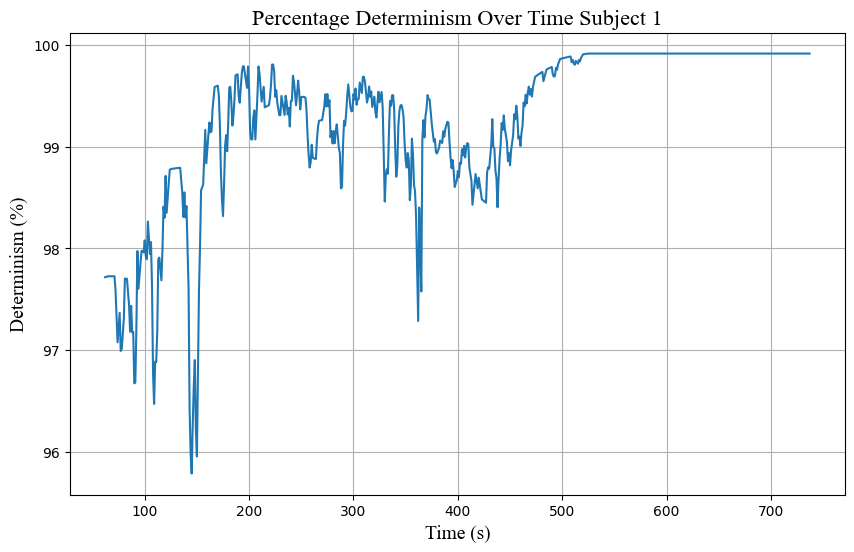

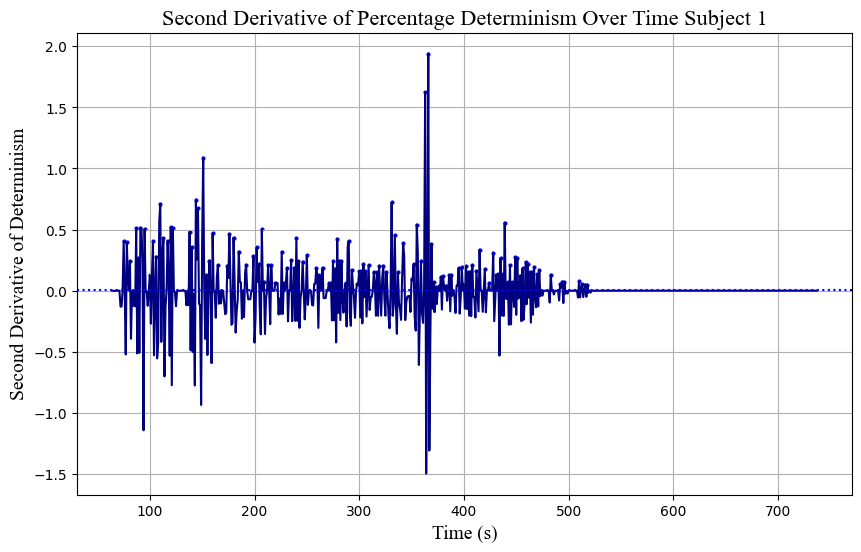

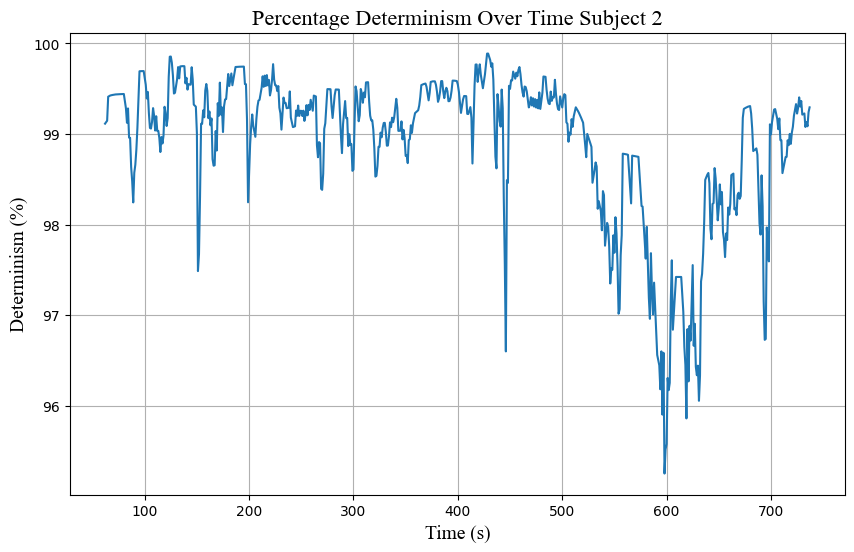

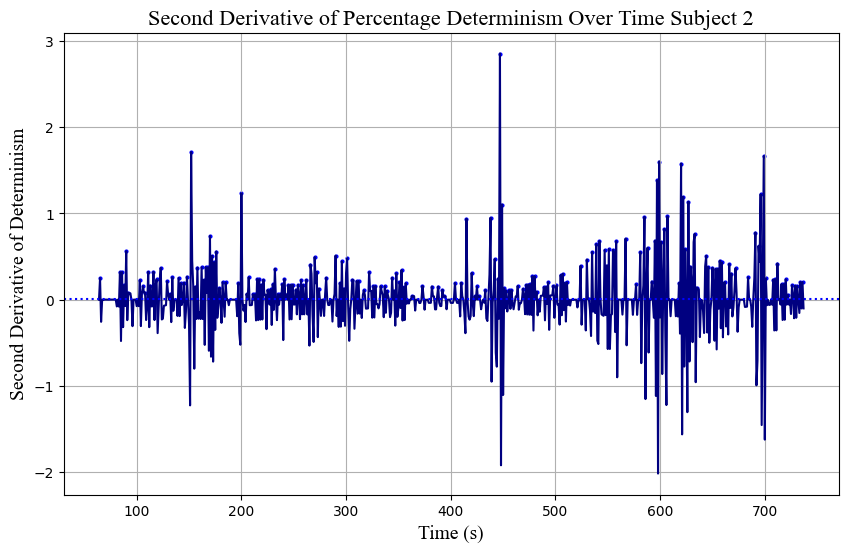

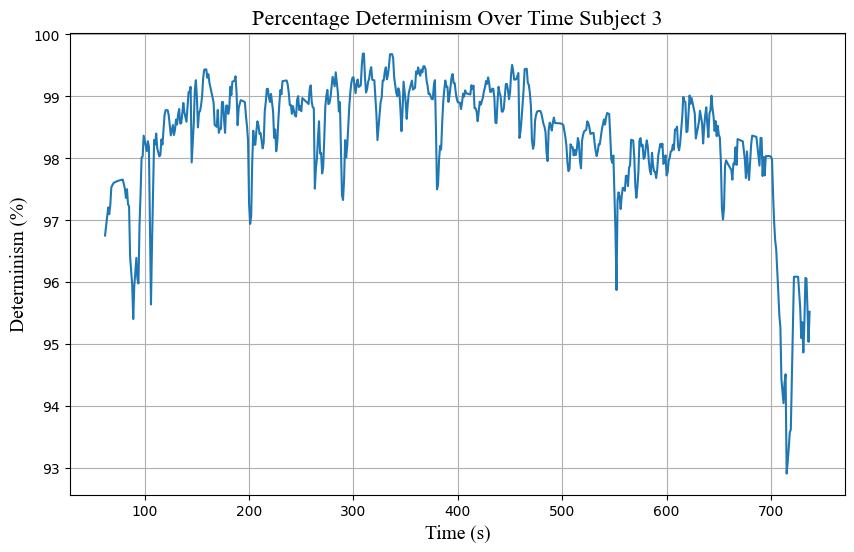

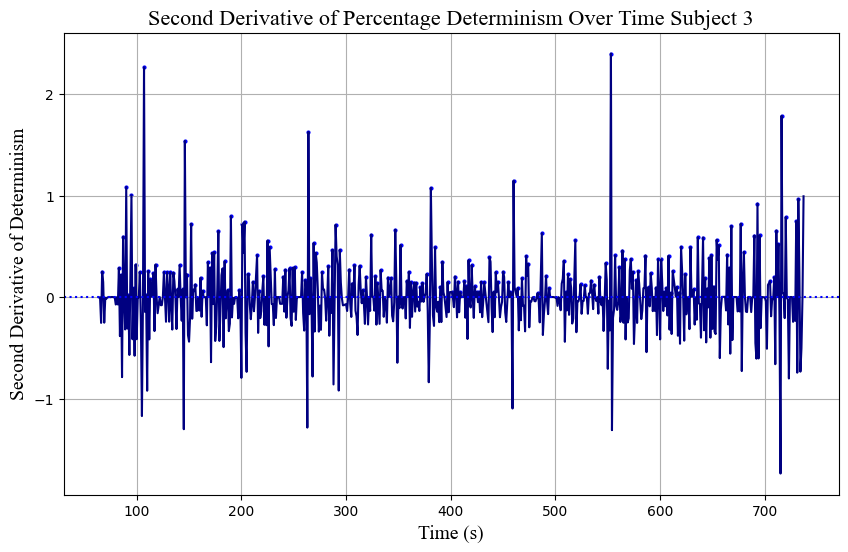

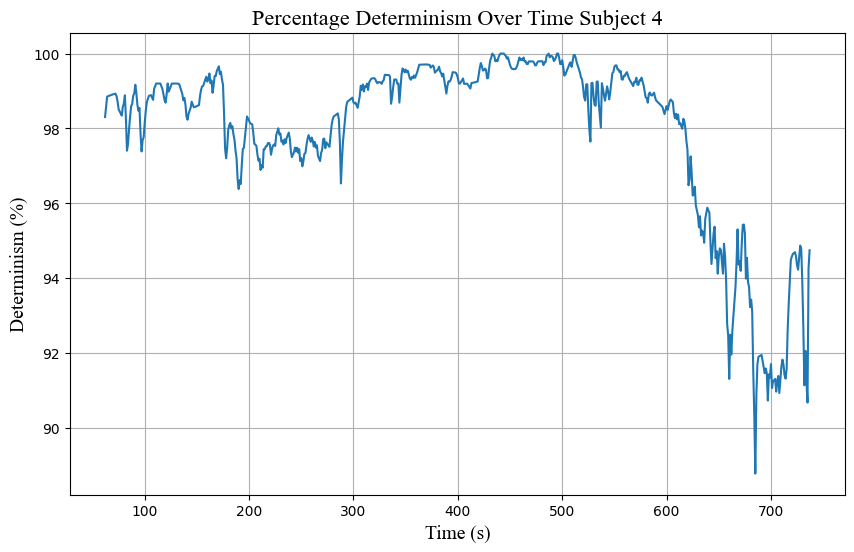

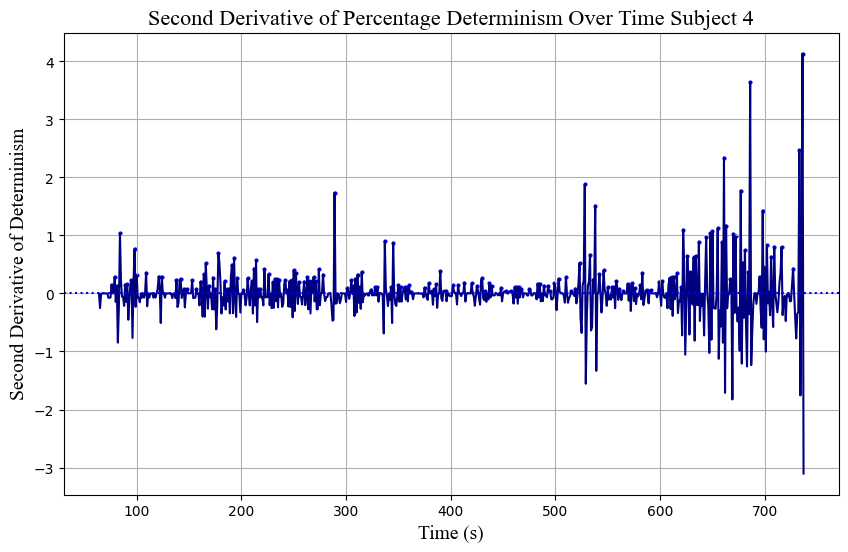

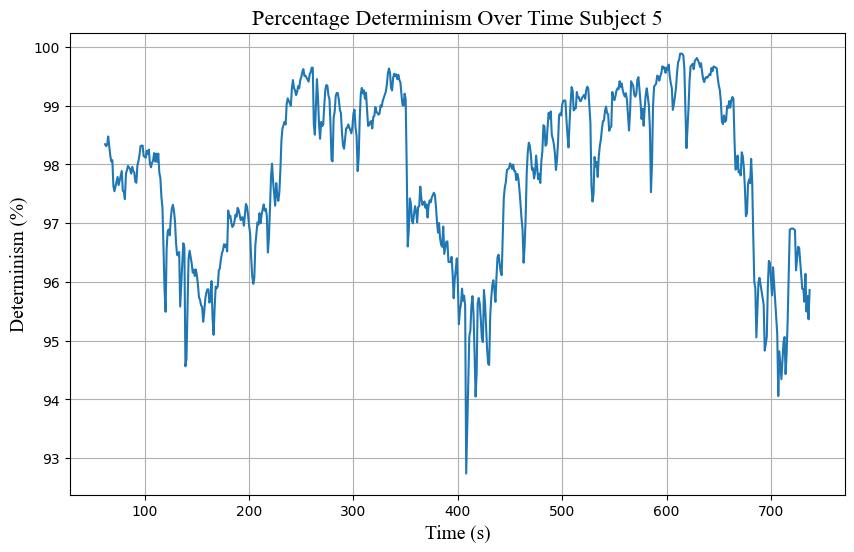

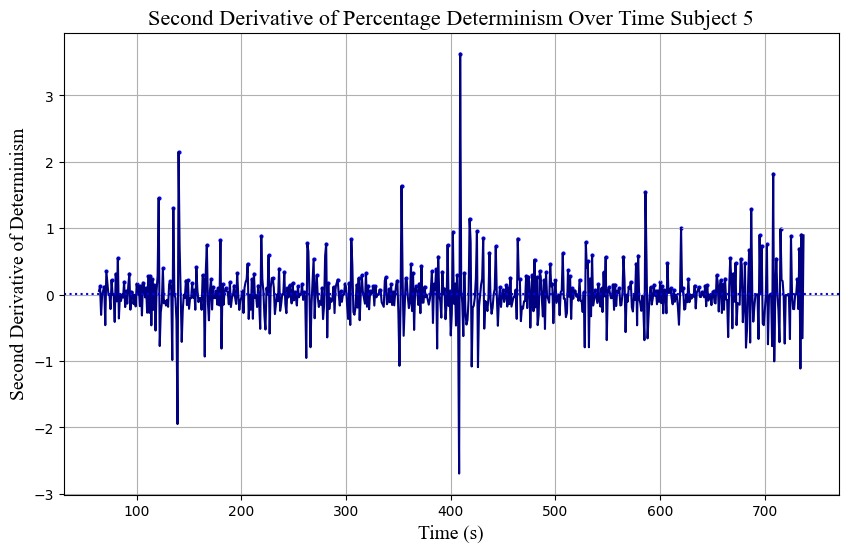

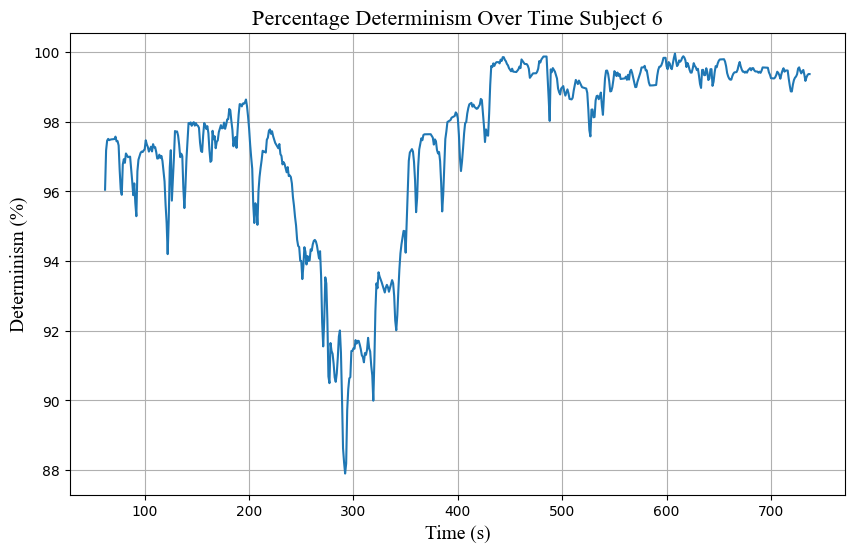

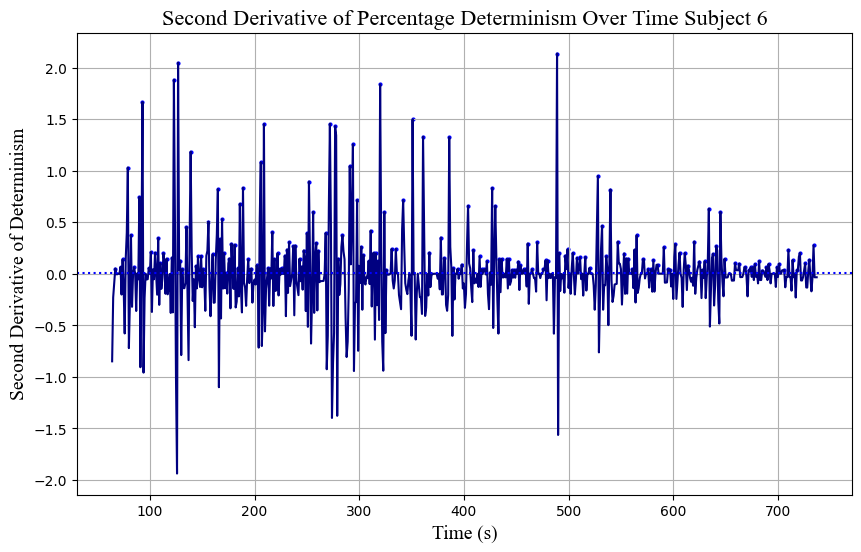

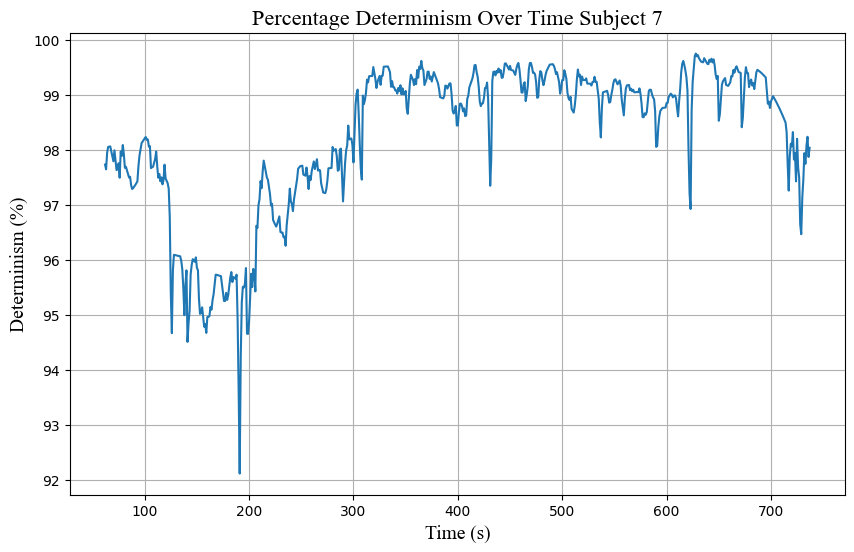

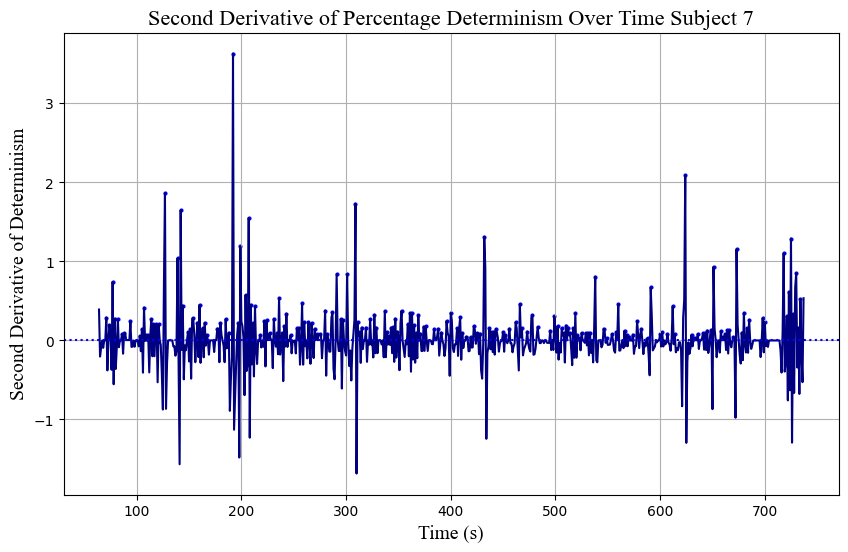

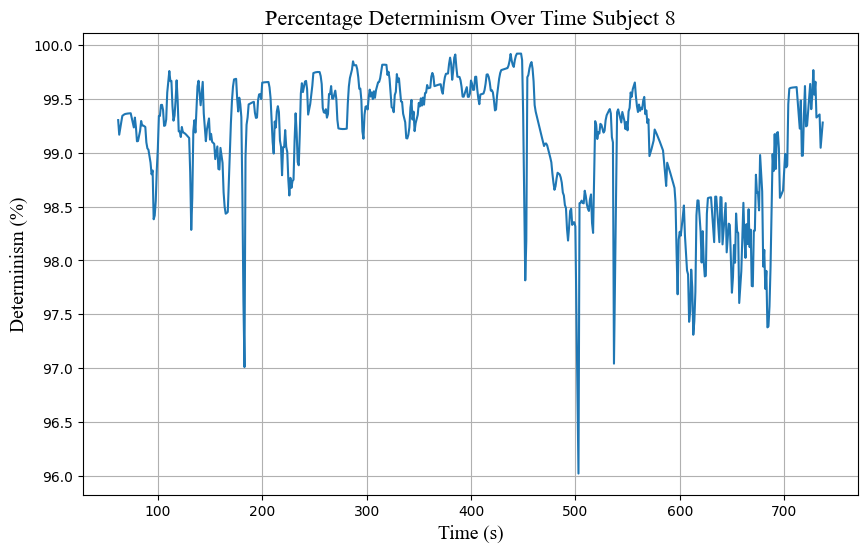

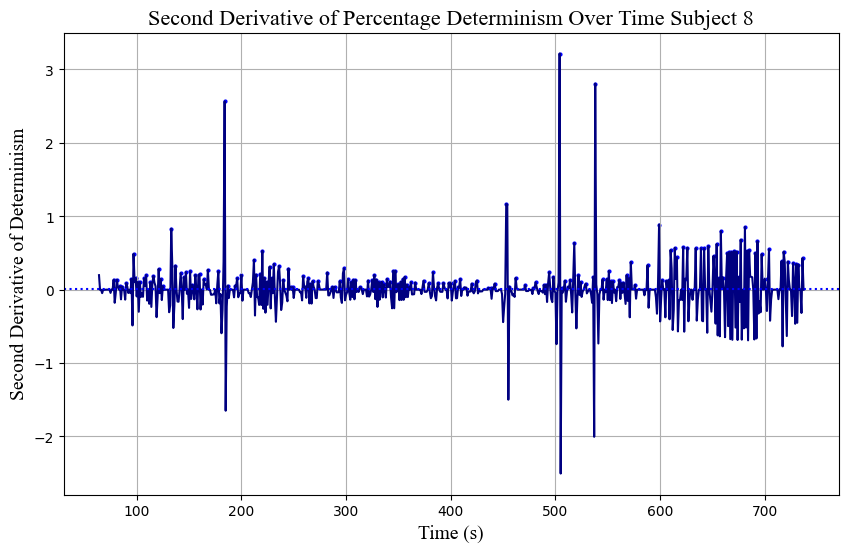

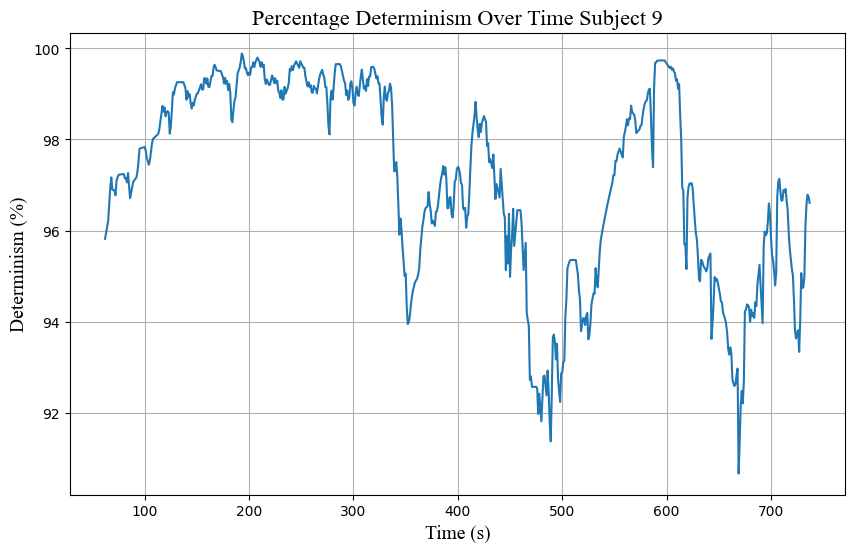

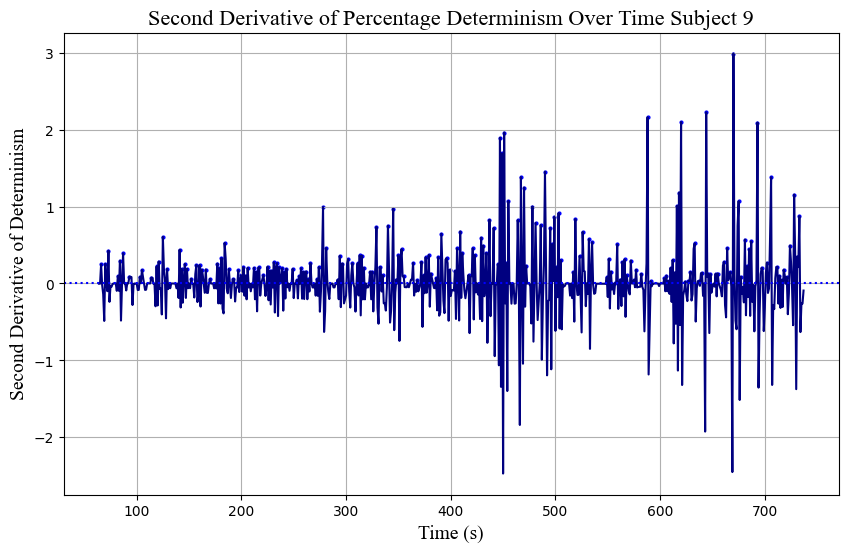

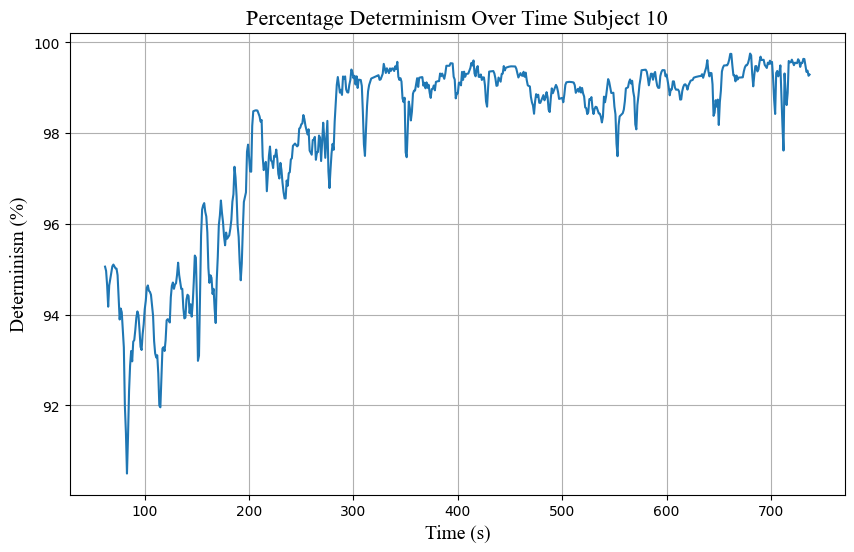

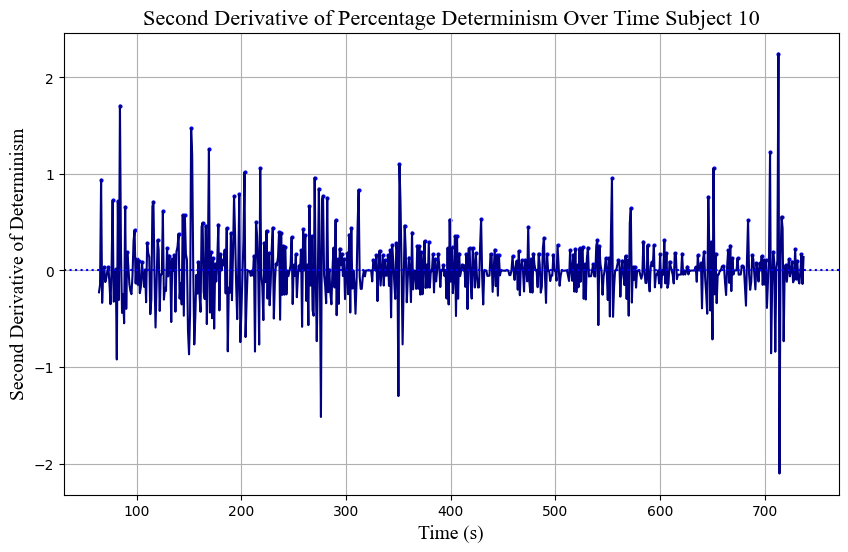

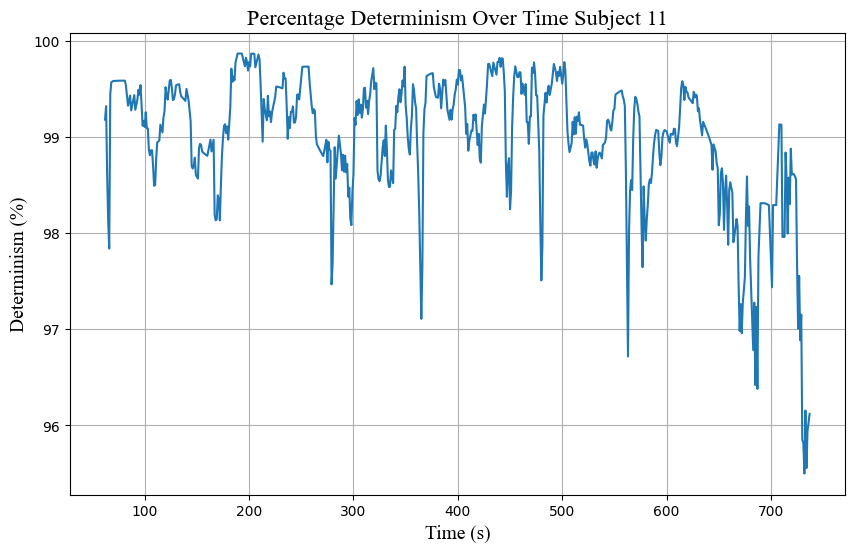

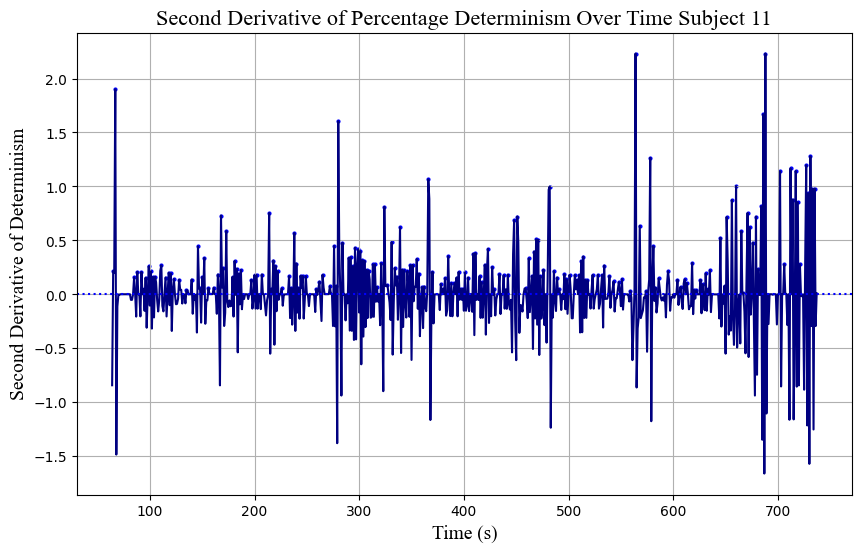

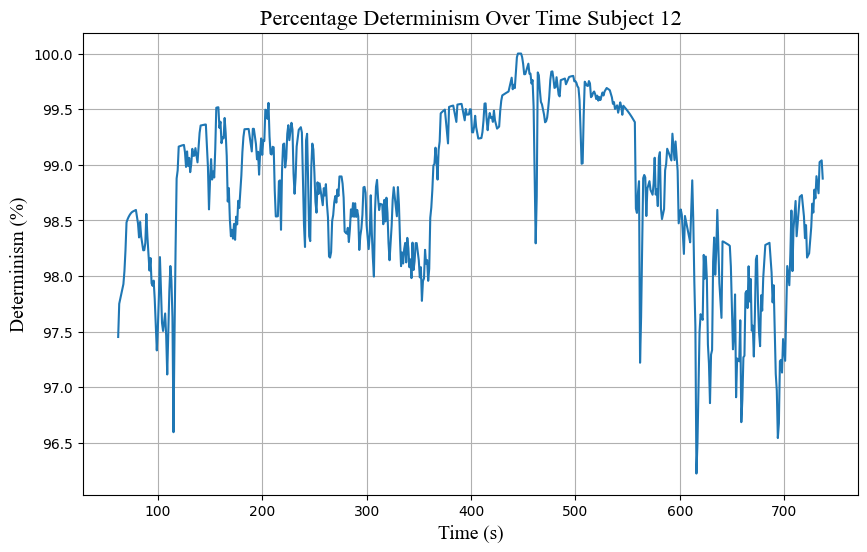

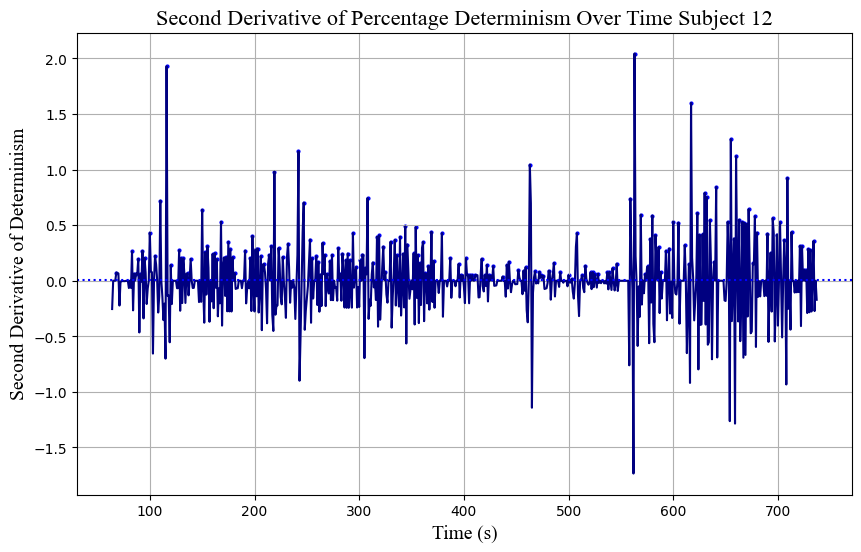

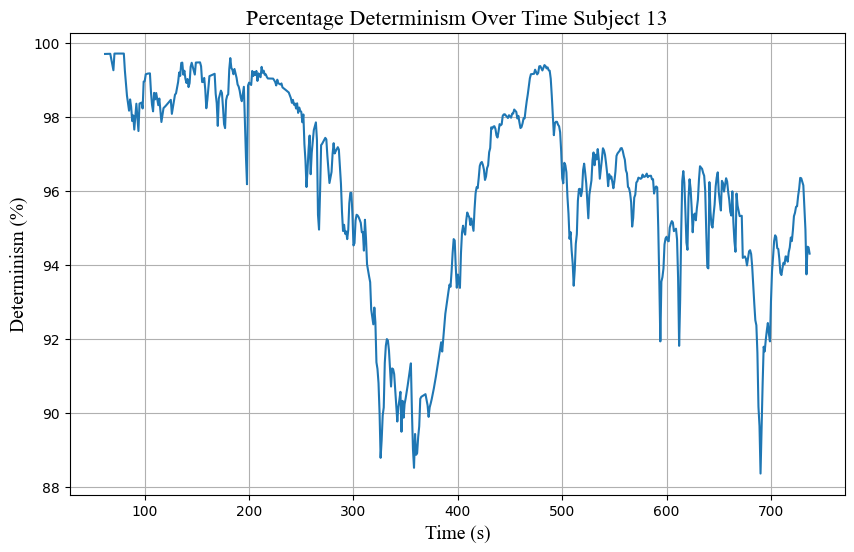

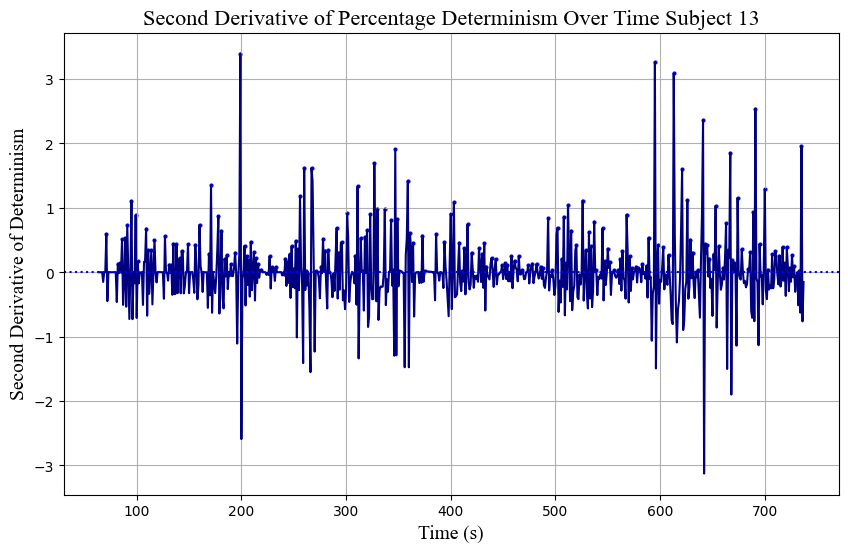

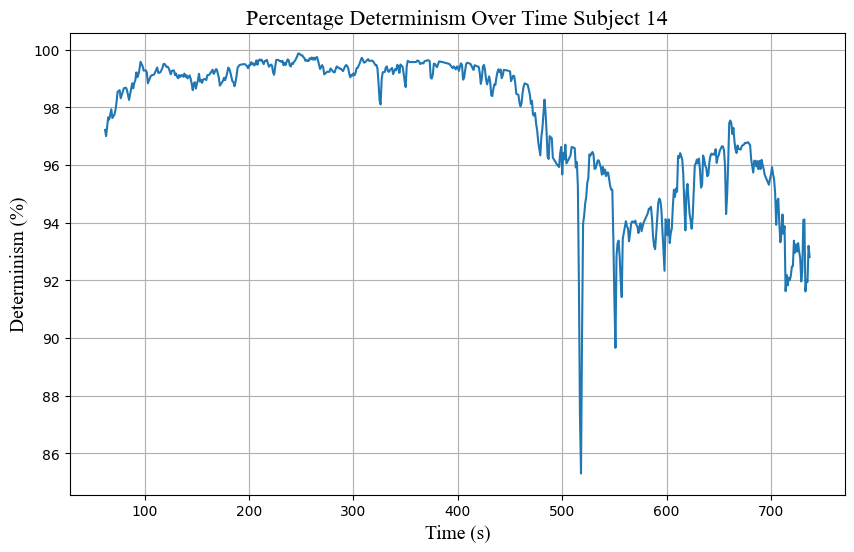

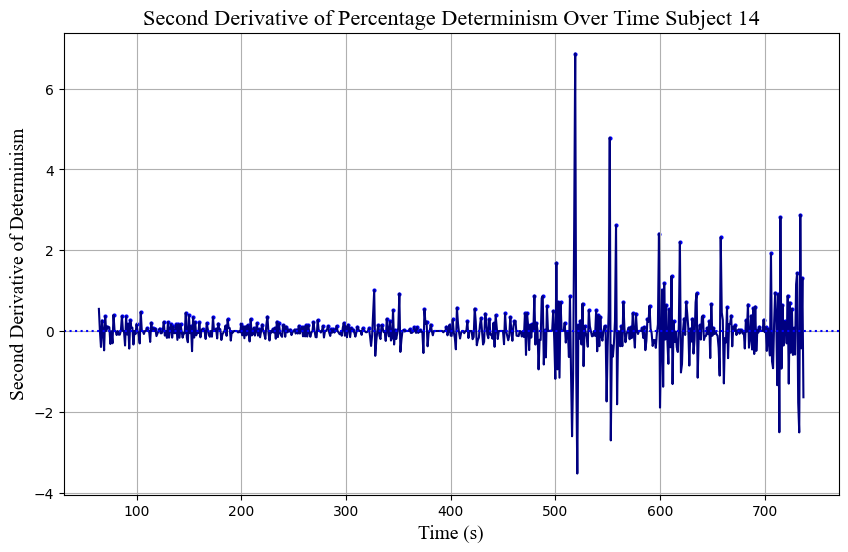

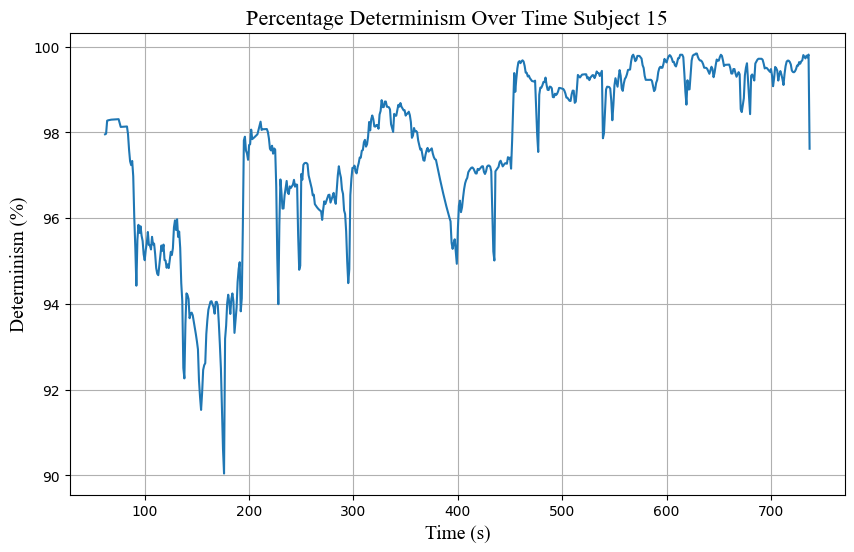

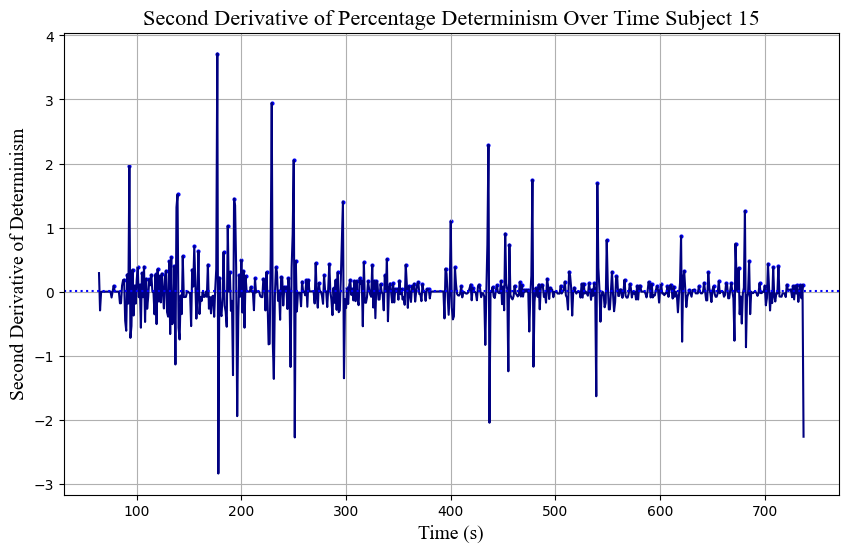

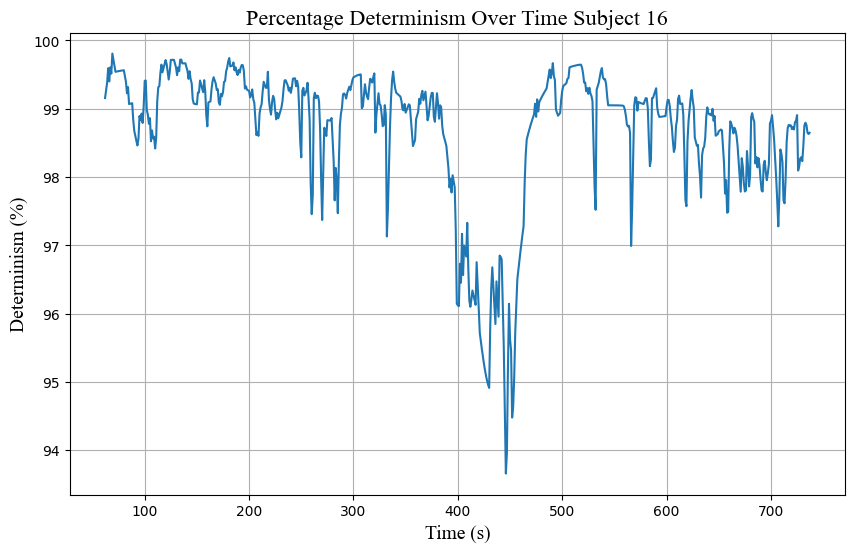

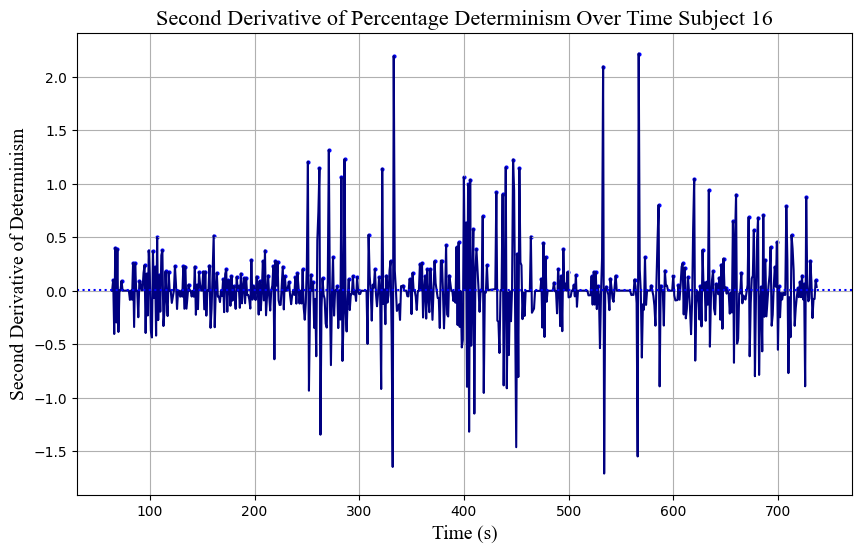

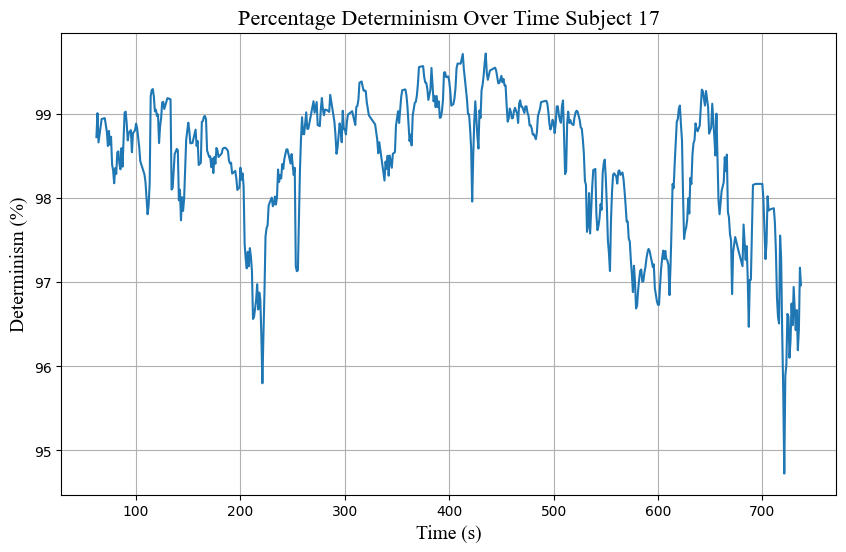

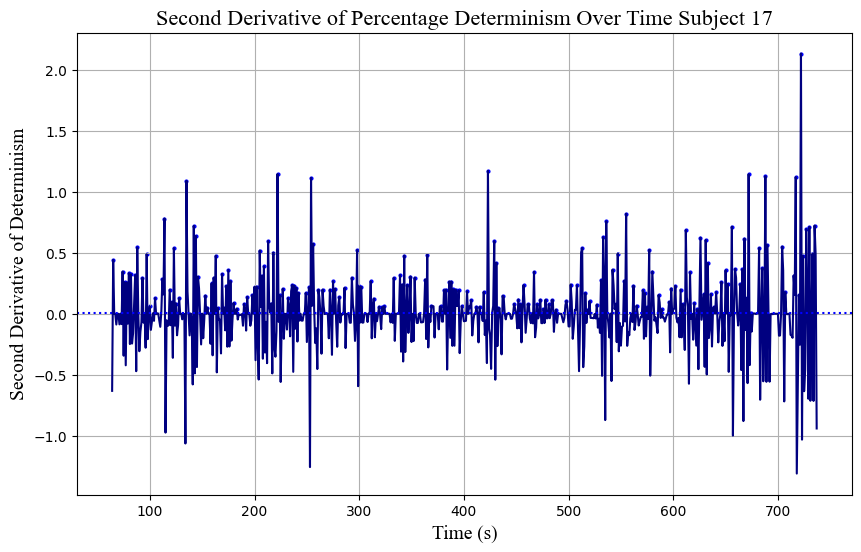

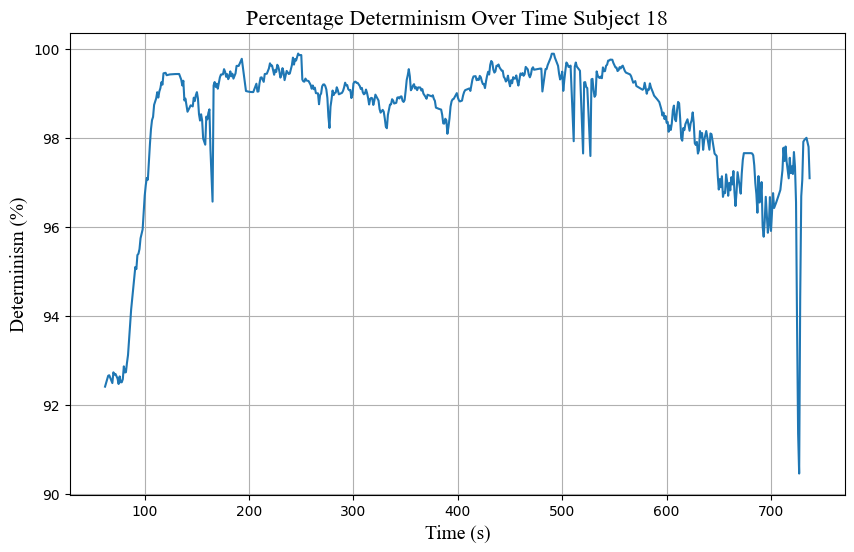

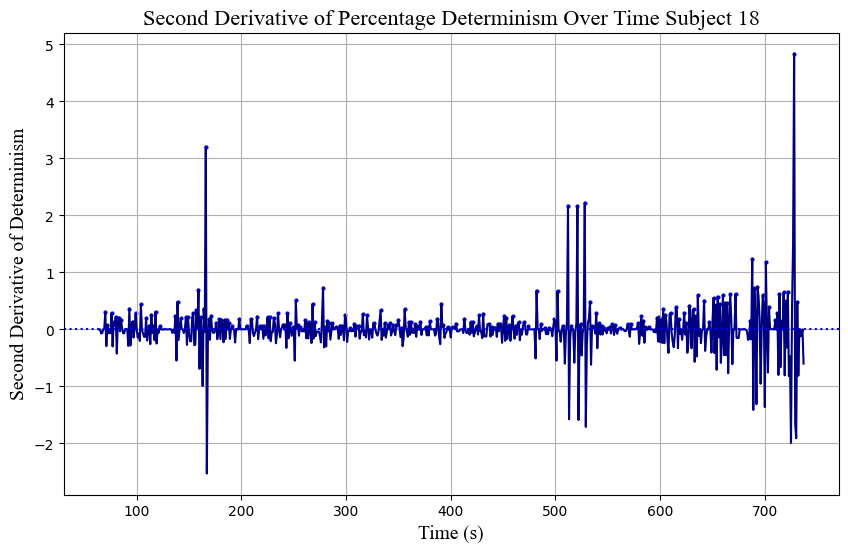

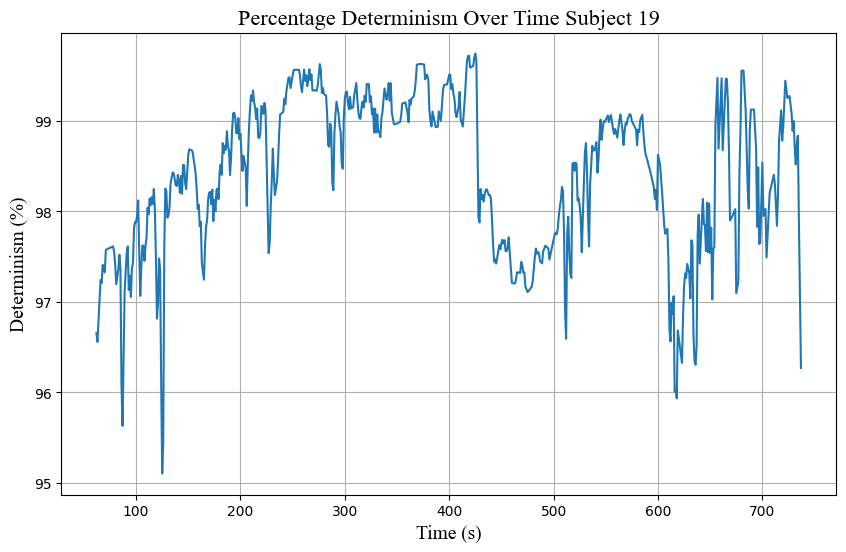

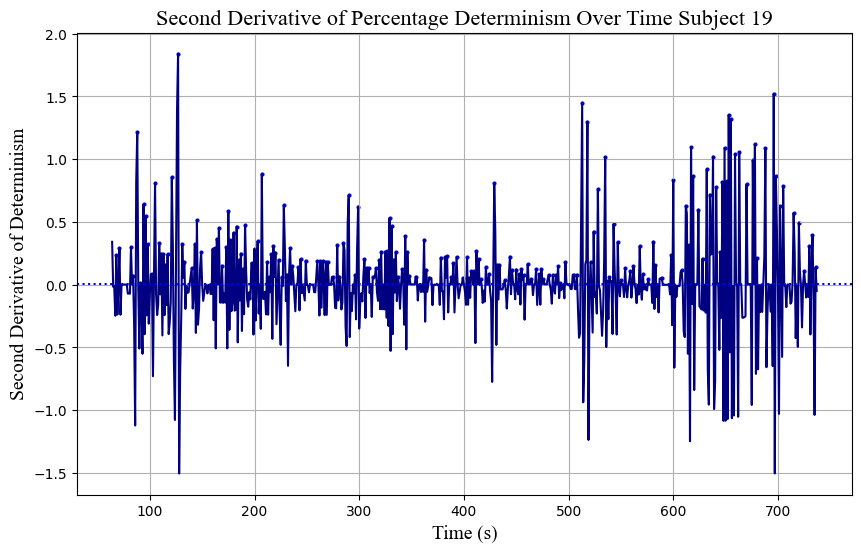

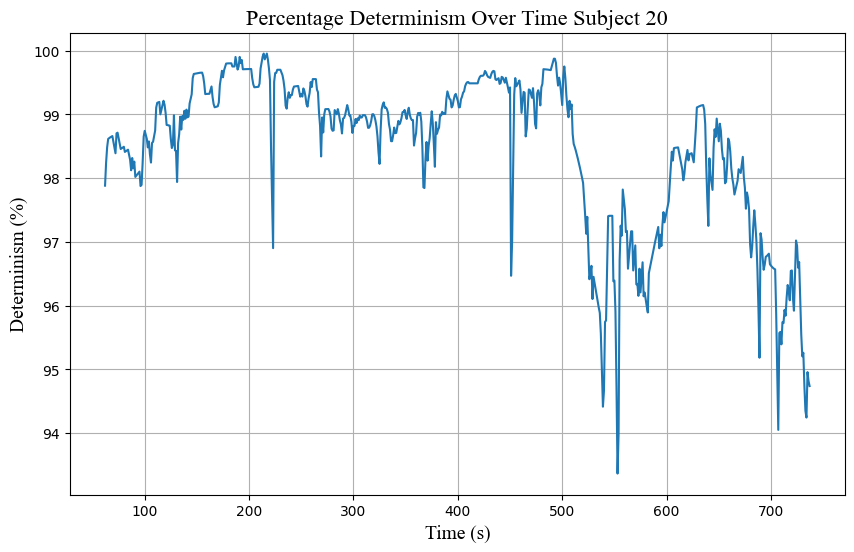

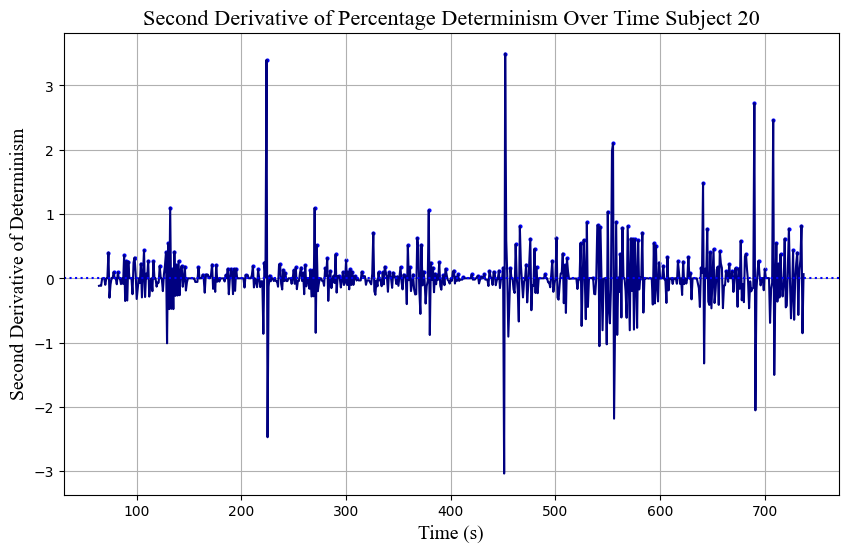

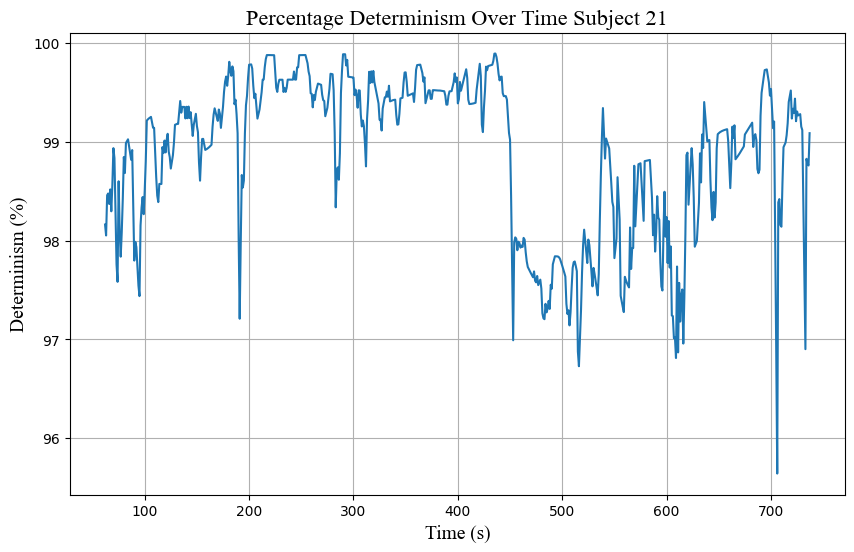

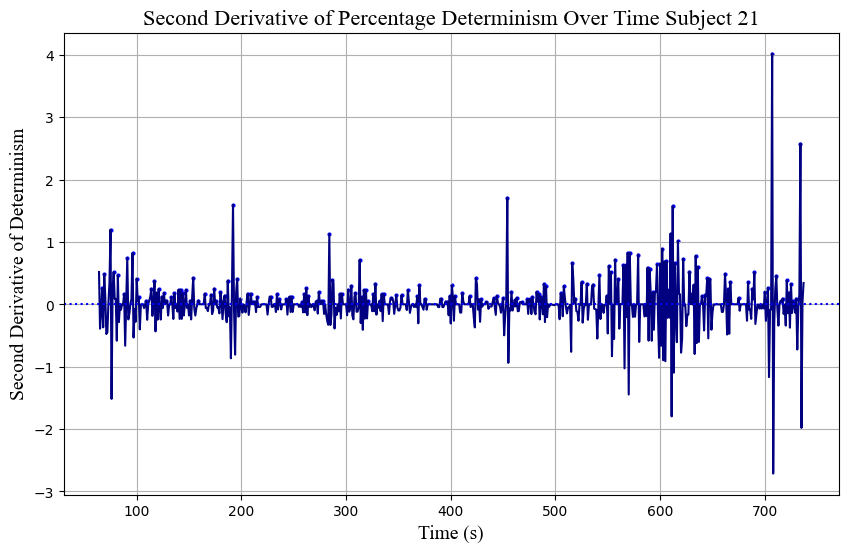

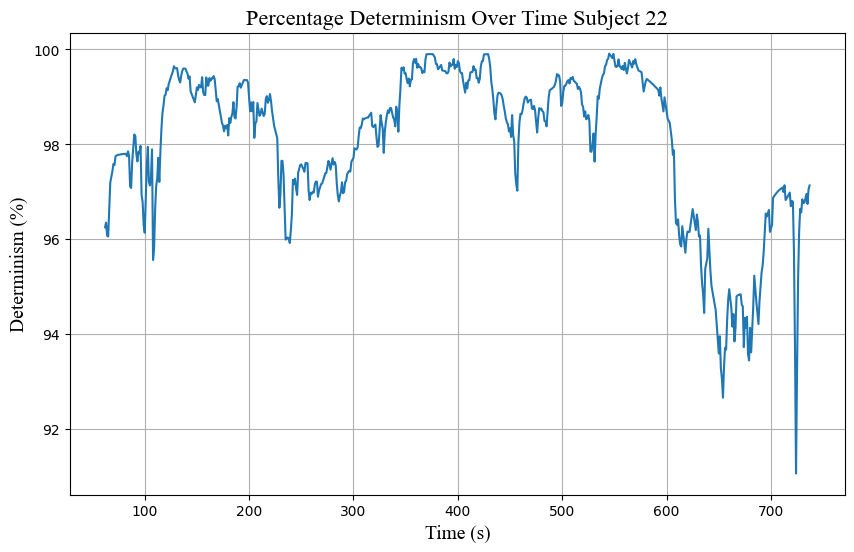

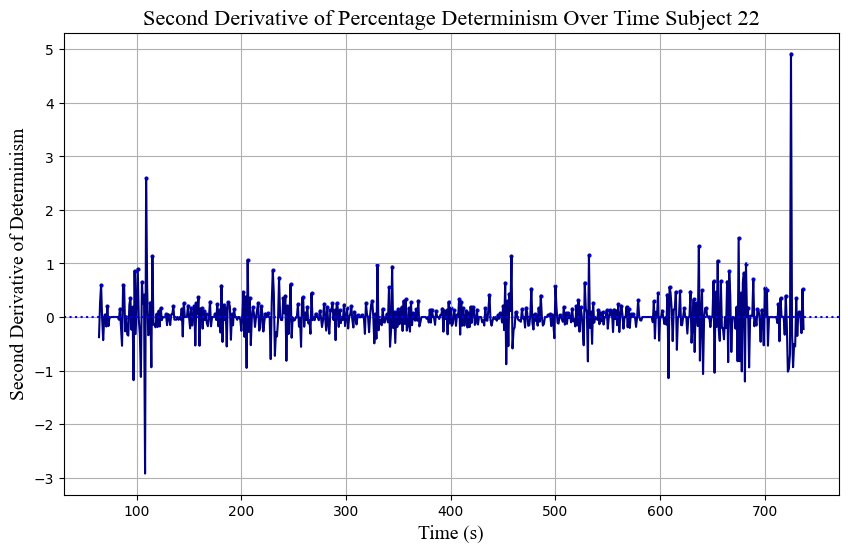

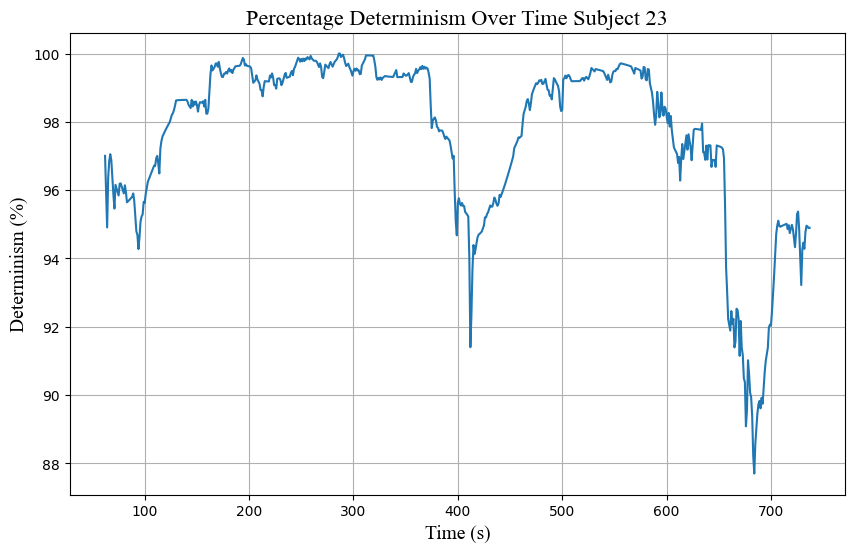

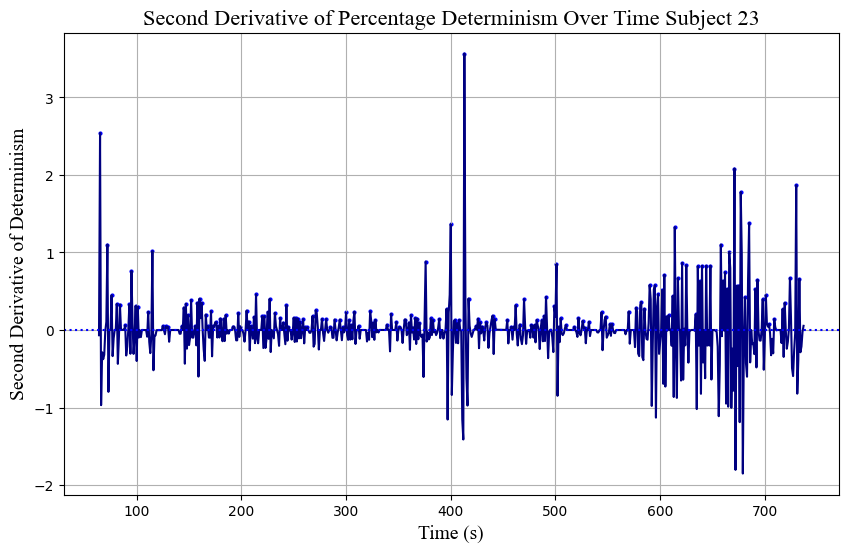

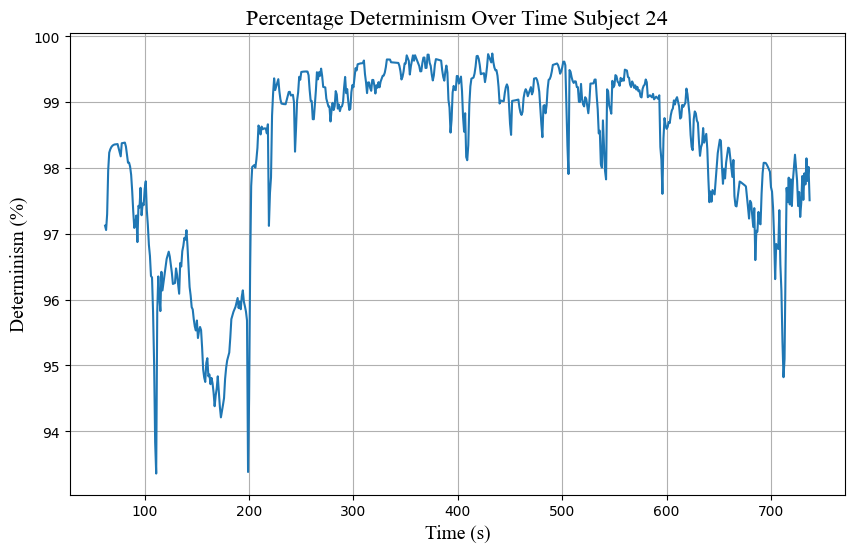

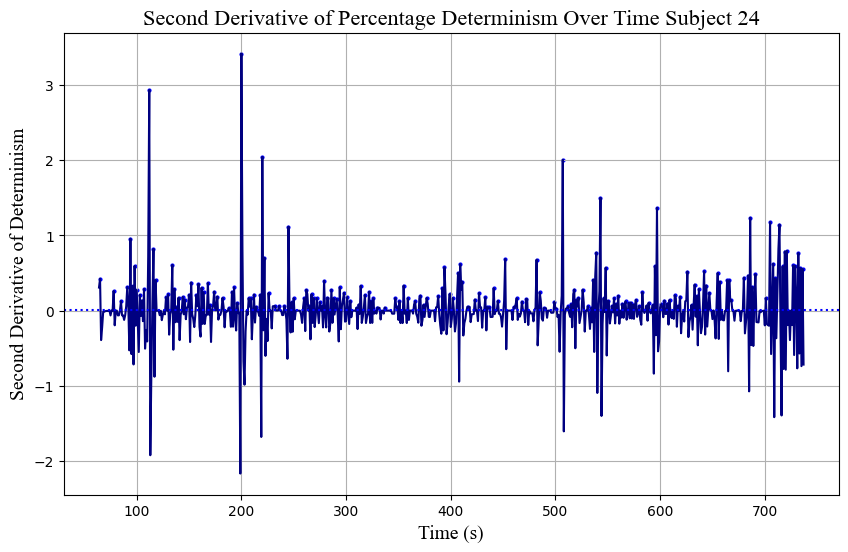

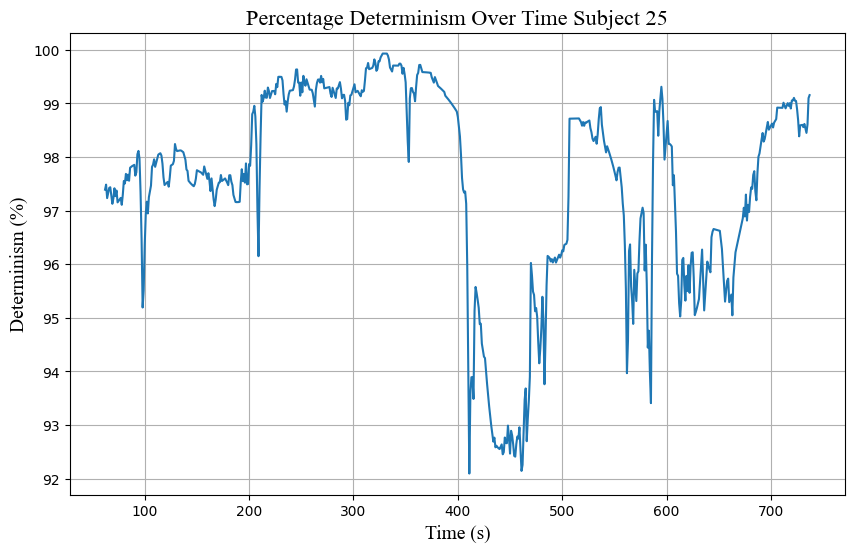

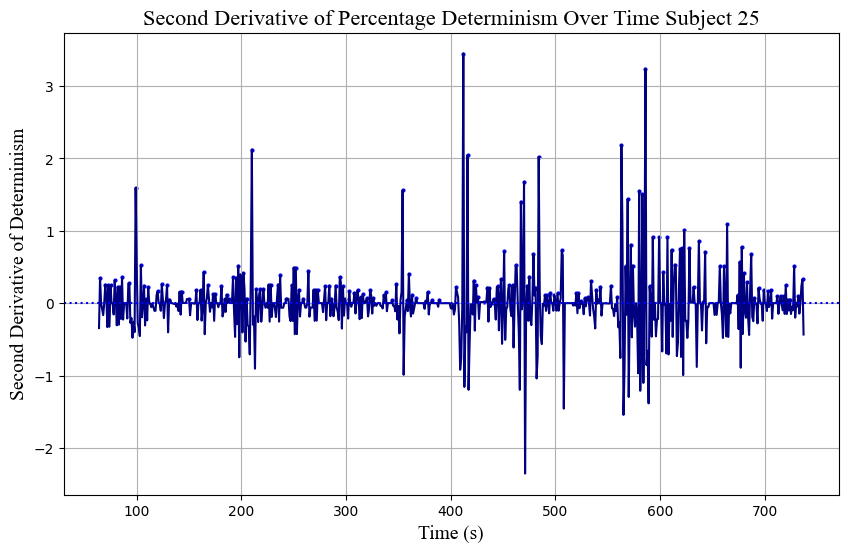

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius

# Plot settings
tnrfont = {'fontname': 'Times New Roman'}
params = {'mathtext.default': 'regular'}
plt.rcParams.update(params)

# RQA parameters
time_interval = 1           # Time intervals after interpolation
epoch_length = 125           # Length of each epoch
step_size = 1                # Step size for moving the epoch
embedding_dim = 7            # Embedding dimension
time_delay = 1               # Time delay (tau)
radius = 5                   # Neighbourhood radius (recurrence threshold)
min_diag_line_length = 4     # Minimum diagonal line length for determinism

# Loop over each subject
for subject in range(1, 26):
    # Define time and heart rate data for the subject
    time = new_df['t'].values
    heart_rate = new_df[f'hr_{subject}'].values

    # Initialize lists for storing RQA results
    determinism_values = []
    time_points = []

    # Perform epoch-by-epoch RQA
    for start in range(0, len(heart_rate) - epoch_length + 1, step_size):
        segment = heart_rate[start:start + epoch_length]
        time_series = TimeSeries(segment, embedding_dimension=embedding_dim, time_delay=time_delay)
        
        # Set up RQA settings
        settings = Settings(time_series, neighbourhood=FixedRadius(radius))

        # Run RQA computation
        rqa_computation = RQAComputation.create(settings)
        rqa_computation.min_diagonal_line_length = 1 #minimum diagonal line length for creating recurrence matrix is 1
        rqa_result = rqa_computation.run()
        rqa_result.min_diagonal_line_length = min_diag_line_length #minimum diagonal line length for calculating determinism is 4

        # Extract percentage determinism (DET%)
        det = rqa_result.determinism
        determinism_values.append(det * 100)  # Convert to percentage

        # Store the midpoint time point of the current epoch
        time_points.append(start + (epoch_length // 2))

    # Convert results to numpy arrays
    determinism_values = np.array(determinism_values)
    time_points = np.array(time_points)

    # Calculate first and second derivatives of determinism
    first_derivative = np.diff(determinism_values) / np.diff(time_points)
    time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
    second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

    # Plot percentage determinism over time
    plt.figure(figsize=(10, 6))
    plt.plot(time_points, determinism_values, linestyle='-')
    plt.xlabel('Time (s)', fontsize=14, **tnrfont)
    plt.ylabel('Determinism (%)', fontsize=14, **tnrfont)
    plt.title(f'Percentage Determinism Over Time Subject {subject}', fontsize=16, **tnrfont)
    plt.grid(True)
    plt.show()

    # Plot second derivative of determinism
    plt.figure(figsize=(10, 6))
    plt.plot(time_points[2:], second_derivative, linestyle='-', color='navy')
    peaks, _ = find_peaks(second_derivative, height=0.005)
    plt.axhline(y=0.005, color='blue', linestyle=':')
    plt.scatter(time_points[2:][peaks], second_derivative[peaks], color='blue', s=4)
    plt.xlabel('Time (s)', fontsize=14, **tnrfont)
    plt.ylabel('Second Derivative of Determinism', fontsize=14, **tnrfont)
    plt.title(f'Second Derivative of Percentage Determinism Over Time Subject {subject}', fontsize=16, **tnrfont)
    plt.grid(True)
    plt.show()

## Optimisation of search window using Bayesian Optimisation
Drawing from physiological knowledge that the anaerobic threshold is expected to occur between the latter half of a subject's heart rate time series, a search window for the AnT is optimised using scikit-optimize's Bayesian optimisation. Instead of searching for the AnT through convex minima in the entire time series, the search window serves as a narrower target for the algorithm. Pearson's correlation coefficient is used as the metric to maximise. 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr, spearmanr
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

# Create a function with the parameters want to optimise as arguments
def rqe(anaerobic_factor_1, anaerobic_factor_2):
    
    # List to collect results for each subject
    results = []

    # Loop over each subject to calculate determinism and its second derivative within the specified range
    for subject in range(1, 26):
        # Define time, heart rate, and AT time
        time = new_df['t'].values
        heart_rate = new_df[f'hr_{subject}'].values
        at_time = AT_secs[subject - 1]

        # Determine the maximum heart rate for this subject and the time when it occurs
        max_hr = np.max(heart_rate)
        max_hr_time = time[np.argmax(heart_rate)]

        # Exclude heart rate data before 30 seconds and after the maximum heart rate time
        filtered_indices = (time >= 30) & (time <= max_hr_time)
        filtered_time = time[filtered_indices]
        filtered_hr = heart_rate[filtered_indices]

        # Interpolation for evenly spaced time intervals
        interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
        regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
        interpolated_hr = interpolator(regular_times)

        # Ensure we have enough data to proceed
        if len(interpolated_hr) < epoch_length:
            print(f"Not enough data for Subject {subject} in the specified range. Skipping.")
            continue

        # Calculate determinism over epochs within the filtered range
        determinism = []
        time_points = []
        for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
            segment = interpolated_hr[start:start + epoch_length]
            time_series = TimeSeries(segment)
        
            # Set RQA settings
            settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
            rqa_computation = RQAComputation.create(settings)
            rqa_computation.min_diagonal_line_length = 1
            rqa_result = rqa_computation.run()
            rqa_result.min_diagonal_line_length = min_diag_line_length
        
            # Extract determinism
            det = rqa_result.determinism
            determinism.append(det * 100)
            time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

        # Convert to numpy arrays for further analysis
        determinism = np.array(determinism)
        time_points = np.array(time_points)
        lower_bound = anaerobic_factor_1 * max_hr_time
        upper_bound = anaerobic_factor_2 * max_hr_time

        # Calculate second derivative of determinism if enough points
        if len(time_points) > 2:
            first_derivative = np.diff(determinism) / np.diff(time_points)
            time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
            second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

            if len(second_derivative) > 0: # Ensure second_derivative is non-empty before finding convex minima
                sorted_minima_indices = np.argsort(second_derivative) # Sort minima indices in ascending order of convexity
    
                # Iterate through the sorted indices to find the first convex minimum within expected range
                convex_minima_time = np.nan  # Default if no valid minima is found
                for idx in sorted_minima_indices:
                    candidate_time = time_points[2:][idx]
        
                    # Check if the candidate is within range 
                    if lower_bound <= candidate_time <= upper_bound: 
                        convex_minima_time = candidate_time
                        break
                    else:
                        convex_minima_time = np.nan
    
            else:
                print(f"No convex minima found for Subject {subject}.")
                convex_minima_time = np.nan

        else:
            print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
            convex_minima_time = np.nan

        # Store the results
        results.append({
            'Subject': subject,
            'AT_time': at_time,
            'Convex_Minima_Time': convex_minima_time
        })

    # Compute correlation score
    convex_minima_times = np.array([r['Convex_Minima_Time'] for r in results if not np.isnan(r['Convex_Minima_Time'])])
    at_times = np.array([r['AT_time'] for r in results if not np.isnan(r['Convex_Minima_Time'])])
    
    if len(convex_minima_times) > 1:
        pearson_corr, _ = pearsonr(convex_minima_times, at_times)
        spearman_corr, _ = spearmanr(convex_minima_times, at_times)
        correlation = (pearson_corr + spearman_corr) / 2  # Averaging both correlations
    else:
        correlation = -1  # Penalise invalid runs

    return -correlation  # Minimise negative correlation to maximise correlation strength

# Define parameter search space
search_space = [
    Real(0.3, 0.8, name='anaerobic_factor_1'), # Factor to scale anaerobic range
    Real(0.6, 1.0, name= 'anaerobic_factor_2')
]

# Run Bayesian Optimisation
result = gp_minimize(lambda x: rqe(*x), search_space, n_calls=30, random_state=42)

# Best parameters found
print("Best Parameters:", result.x)
print("Best Correlation Strength:", -result.fun)

Best Parameters: [0.6898455001363848, 0.8387400631785948]
Best Correlation Strength: 0.758000687399171


In [11]:
import pandas as pd

# Extract all function evaluations
param_history = result.x_iters  # List of parameter sets tested
score_history = [-score for score in result.func_vals]  # Convert negative correlation back to positive

# Create a DataFrame for better readability
history_df = pd.DataFrame(param_history, columns=['anaerobic_factor_1', 'anaerobic_factor_2'])
history_df['correlation'] = score_history

# Display sorted results (highest correlation first)
history_df_sorted = history_df.sort_values(by='correlation', ascending=False)
print(history_df_sorted)


    anaerobic_factor_1  anaerobic_factor_2  correlation
1             0.689846            0.838740     0.758001
29            0.564217            0.826665     0.744404
19            0.785864            0.910933     0.731634
25            0.453471            0.600000     0.727640
17            0.574087            0.870859     0.722465
21            0.800000            1.000000     0.721608
28            0.800000            0.909994     0.721608
18            0.476902            0.686131     0.720899
13            0.747150            1.000000     0.718878
26            0.632120            0.879901     0.717737
23            0.683829            0.875313     0.715869
27            0.739048            0.879221     0.713069
7             0.796106            0.846993     0.705772
3             0.529624            0.733483     0.695821
11            0.706757            0.927539     0.679058
2             0.522916            0.639990     0.678572
16            0.376462            0.600000     0

A wide initial search between 0.3-0.8 and 0.6-1.0 yields __0.564217-0.826665__ as a promising window, with 0.68946-0.838740 disregarded due to its narrower size and limited improved correlation. This window is now applied as the search window, with the algorithm identifying the most convex minimum of percentage determinism within this window as the anaerobic threshold of the subject.

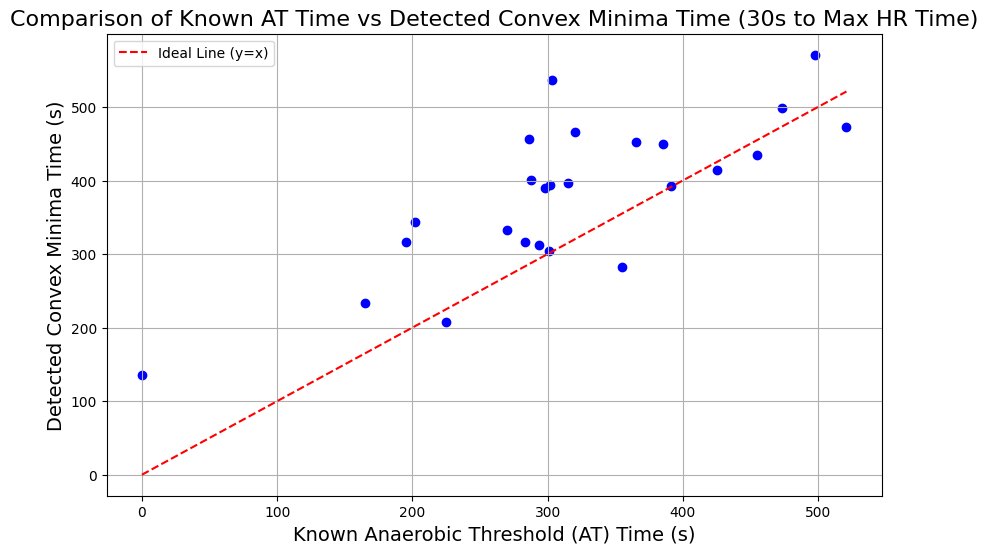

    Subject  AT_time  Convex_Minima_Time
0         1    195.0               317.0
1         2    283.0               316.0
2         3    320.0               466.0
3         4    391.0               393.0
4         5    473.0               499.0
5         6    521.0               473.0
6         7    303.0               537.0
7         8    202.0               343.0
8         9    165.0               233.0
9        10    498.0               571.0
10       11    365.0               452.0
11       12    288.0               401.0
12       13      0.0               136.0
13       14    355.0               283.0
14       15    455.0               434.0
15       16    225.0               208.0
16       17    286.0               456.0
17       18    298.0               390.0
18       19    315.0               397.0
19       20    301.0               304.0
20       21    294.0               312.0
21       22    425.0               414.0
22       23    302.0               394.0
23       24    3

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

# List to collect results for each subject
results = []

# Loop over each subject to calculate determinism and its second derivative within the specified range
for subject in range(1, 26):
    # Define time, heart rate, and AT time
    time = new_df['t'].values
    heart_rate = new_df[f'hr_{subject}'].values
    at_time = AT_secs[subject - 1]

    # Determine the maximum heart rate for this subject and the time when it occurs
    max_hr = np.max(heart_rate)
    max_hr_time = time[np.argmax(heart_rate)]

    # Exclude heart rate data before 30 seconds and after the maximum heart rate time
    filtered_indices = (time >= 30) & (time <= max_hr_time)
    filtered_time = time[filtered_indices]
    filtered_hr = heart_rate[filtered_indices]

    # Interpolation for evenly spaced time intervals
    interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
    regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
    interpolated_hr = interpolator(regular_times)

    # Ensure we have enough data to proceed
    if len(interpolated_hr) < epoch_length:
        print(f"Not enough data for Subject {subject} in the specified range. Skipping.")
        continue

    # Calculate determinism over epochs within the filtered range
    determinism = []
    time_points = []
    for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
        segment = interpolated_hr[start:start + epoch_length]
        time_series = TimeSeries(segment)
        
        # Set RQA settings
        settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
        rqa_computation = RQAComputation.create(settings)
        rqa_computation.min_diagonal_line_length = 1
        rqa_result = rqa_computation.run()
        rqa_result.min_diagonal_line_length = min_diag_line_length
        
        # Extract determinism
        det = rqa_result.determinism
        determinism.append(det * 100)
        time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

    # Convert to numpy arrays for further analysis
    determinism = np.array(determinism)
    time_points = np.array(time_points)
    lower_bound = 0.564217 * max_hr_time
    upper_bound = 0.826665 * max_hr_time

    # Calculate second derivative of determinism if enough points
    if len(time_points) > 2:
        first_derivative = np.diff(determinism) / np.diff(time_points)
        time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
        second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

        if len(second_derivative) > 0: # Ensure second_derivative is non-empty before finding convex minima
            sorted_minima_indices = np.argsort(second_derivative) # Sort minima indices in ascending order of convexity
    
            # Iterate through the sorted indices to find the first convex minimum within expected range
            convex_minima_time = np.nan  # Default if no valid minima is found
            for idx in sorted_minima_indices:
                candidate_time = time_points[2:][idx]
        
                # Check if the candidate is within range 
                if lower_bound <= candidate_time <= upper_bound: 
                    convex_minima_time = candidate_time
                    break
                else:
                    convex_minima_time = np.nan
    
        else:
            print(f"No convex minima found for Subject {subject}.")
            convex_minima_time = np.nan

    else:
        print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
        convex_minima_time = np.nan

    # Store the results
    results.append({
        'Subject': subject,
        'AT_time': at_time,
        'Convex_Minima_Time': convex_minima_time
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df['AT_time'] = results_df['AT_time'].astype(float)
results_df['Convex_Minima_Time'] = results_df['Convex_Minima_Time'].astype(float)

# Scatterplot of Convex Minima Time vs Known AT Time
plt.figure(figsize=(10, 6))
plt.scatter(results_df['AT_time'], results_df['Convex_Minima_Time'], color='blue')
plt.plot([results_df['AT_time'].min(), results_df['AT_time'].max()],
         [results_df['AT_time'].min(), results_df['AT_time'].max()],
         color='red', linestyle='--', label='Ideal Line (y=x)')
plt.xlabel('Known Anaerobic Threshold (AT) Time (s)', fontsize=14)
plt.ylabel('Detected Convex Minima Time (s)', fontsize=14)
plt.title('Comparison of Known AT Time vs Detected Convex Minima Time (30s to Max HR Time)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Display the results
print(results_df)

Pearson Correlation: 0.691, p-value: 0.00019
Spearman Correlation: 0.676, p-value: 0.00029


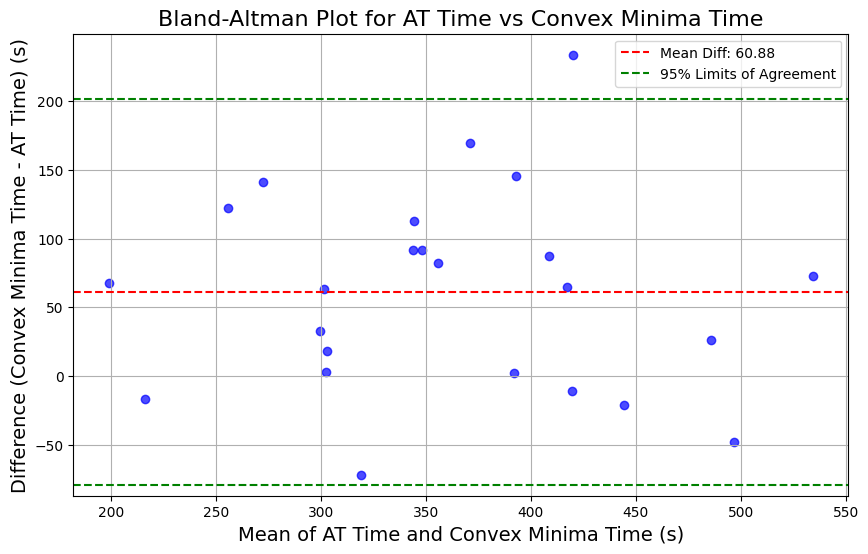

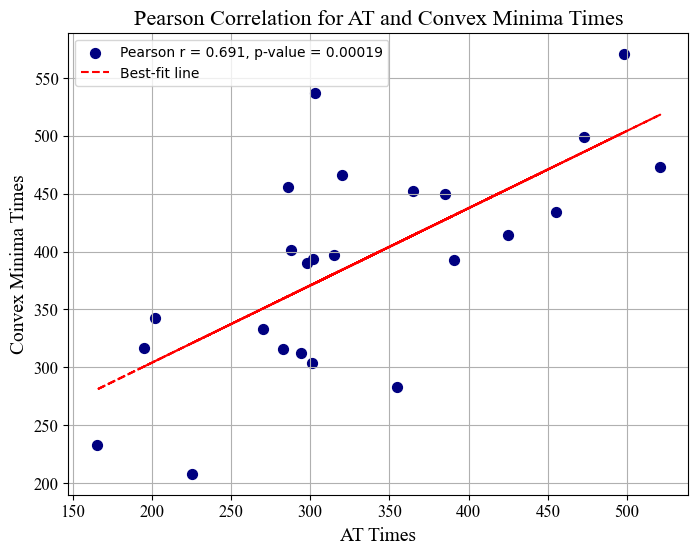

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude subject 13
filtered_results = results_df[results_df['Subject'] != 13].dropna(subset=['AT_time', 'Convex_Minima_Time'])

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

Although the results look promising, another, more targeted Bayesian Optimisation search is carried out to idenfity potential higher performing windows, between 0.5-0.6 and 0.75-0.9.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr, spearmanr
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

def rqe(anaerobic_factor_1, anaerobic_factor_2):
    
    # List to collect results for each subject
    results = []

    # Loop over each subject to calculate determinism and its second derivative within the specified range
    for subject in range(1, 26):
        # Define time, heart rate, and AT time
        time = new_df['t'].values
        heart_rate = new_df[f'hr_{subject}'].values
        at_time = AT_secs[subject - 1]

        # Determine the maximum heart rate for this subject and the time when it occurs
        max_hr = np.max(heart_rate)
        max_hr_time = time[np.argmax(heart_rate)]

        # Exclude heart rate data before 30 seconds and after the maximum heart rate time
        filtered_indices = (time >= 30) & (time <= max_hr_time)
        filtered_time = time[filtered_indices]
        filtered_hr = heart_rate[filtered_indices]

        # Interpolation for evenly spaced time intervals
        interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
        regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
        interpolated_hr = interpolator(regular_times)

        # Ensure we have enough data to proceed
        if len(interpolated_hr) < epoch_length:
            print(f"Not enough data for Subject {subject} in the specified range. Skipping.")
            continue

        # Calculate determinism over epochs within the filtered range
        determinism = []
        time_points = []
        for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
            segment = interpolated_hr[start:start + epoch_length]
            time_series = TimeSeries(segment)
        
            # Set RQA settings
            settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
            rqa_computation = RQAComputation.create(settings)
            rqa_computation.min_diagonal_line_length = 1
            rqa_result = rqa_computation.run()
            rqa_result.min_diagonal_line_length = min_diag_line_length
        
            # Extract determinism
            det = rqa_result.determinism
            determinism.append(det * 100)
            time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

        # Convert to numpy arrays for further analysis
        determinism = np.array(determinism)
        time_points = np.array(time_points)
        lower_bound = anaerobic_factor_1 * max_hr_time
        upper_bound = anaerobic_factor_2 * max_hr_time

        # Calculate second derivative of determinism if enough points
        if len(time_points) > 2:
            first_derivative = np.diff(determinism) / np.diff(time_points)
            time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
            second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

            if len(second_derivative) > 0: # Ensure second_derivative is non-empty before finding convex minima
                sorted_minima_indices = np.argsort(second_derivative) # Sort minima indices in ascending order of convexity
    
                # Iterate through the sorted indices to find the first convex minimum within expected range
                convex_minima_time = np.nan  # Default if no valid minima is found
                for idx in sorted_minima_indices:
                    candidate_time = time_points[2:][idx]
        
                    # Check if the candidate is within range 
                    if lower_bound <= candidate_time <= upper_bound: 
                        convex_minima_time = candidate_time
                        break
                    else:
                        convex_minima_time = np.nan
    
            else:
                print(f"No convex minima found for Subject {subject}.")
                convex_minima_time = np.nan

        else:
            print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
            convex_minima_time = np.nan

        # Store the results
        results.append({
            'Subject': subject,
            'AT_time': at_time,
            'Convex_Minima_Time': convex_minima_time
        })

    # Compute correlation score 
    convex_minima_times = np.array([r['Convex_Minima_Time'] for r in results if not np.isnan(r['Convex_Minima_Time'])])
    at_times = np.array([r['AT_time'] for r in results if not np.isnan(r['Convex_Minima_Time'])])
    
    if len(convex_minima_times) > 1:
        pearson_corr, _ = pearsonr(convex_minima_times, at_times)
        spearman_corr, _ = spearmanr(convex_minima_times, at_times)
        correlation = (pearson_corr + spearman_corr) / 2  # Averaging both correlations
    else:
        correlation = -1  # Penalise invalid runs

    return -correlation  # Minimise negative correlation to maximise correlation strength

# Define parameter search space
search_space = [
    Real(0.5, 0.6, name='anaerobic_factor_1'), # Factor to scale anaerobic range
    Real(0.75, 0.9, name= 'anaerobic_factor_2')
]

# Run Bayesian Optimisation
result = gp_minimize(lambda x: rqe(*x), search_space, n_calls=10, random_state=42)

# Best parameters found
print("Best Parameters:", result.x)
print("Best Correlation Strength:", -result.fun)

Best Parameters: [0.593855270901575, 0.7501168148761521]
Best Correlation Strength: 0.7742974460644141


In [9]:
import pandas as pd

# Extract all function evaluations
param_history = result.x_iters  # List of parameter sets tested
score_history = [-score for score in result.func_vals]  # Convert negative correlation back to positive

# Create a DataFrame for better readability
history_df = pd.DataFrame(param_history, columns=['anaerobic_factor_1', 'anaerobic_factor_2'])
history_df['correlation'] = score_history

# Display sorted results (highest correlation first)
history_df_sorted = history_df.sort_values(by='correlation', ascending=False)
print(history_df_sorted)


   anaerobic_factor_1  anaerobic_factor_2  correlation
6            0.593855            0.750117     0.774297
0            0.579654            0.777515     0.768355
7            0.599221            0.842622     0.766552
8            0.561165            0.751060     0.761504
1            0.577969            0.839528     0.743913
2            0.544583            0.764996     0.717392
3            0.545925            0.800056     0.712243
9            0.502306            0.828716     0.632544
4            0.514287            0.847633     0.585471
5            0.505641            0.858300     0.549928


0.6-0.85 is identified as a relatively wide window that achieves a high correlation and is now regarded as the final search window. 

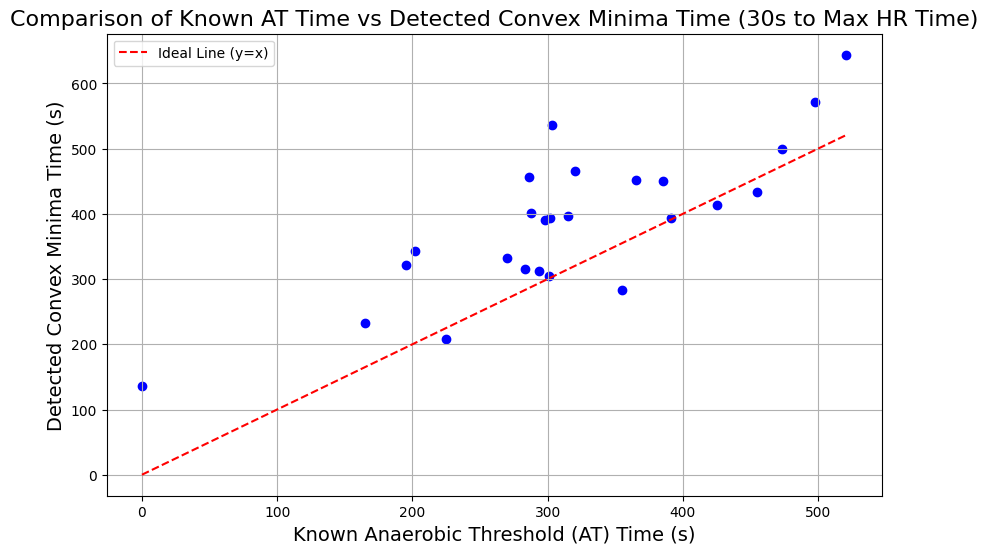

    Subject  AT_time  Convex_Minima_Time
0         1    195.0               321.0
1         2    283.0               316.0
2         3    320.0               466.0
3         4    391.0               393.0
4         5    473.0               499.0
5         6    521.0               644.0
6         7    303.0               537.0
7         8    202.0               343.0
8         9    165.0               233.0
9        10    498.0               571.0
10       11    365.0               452.0
11       12    288.0               401.0
12       13      0.0               136.0
13       14    355.0               283.0
14       15    455.0               434.0
15       16    225.0               208.0
16       17    286.0               456.0
17       18    298.0               390.0
18       19    315.0               397.0
19       20    301.0               304.0
20       21    294.0               312.0
21       22    425.0               414.0
22       23    302.0               394.0
23       24    3

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

# List to collect results for each subject
results = []

# Loop over each subject to calculate determinism and its second derivative within the specified range
for subject in range(1, 26):
    # Define time, heart rate, and AT time
    time = new_df['t'].values
    heart_rate = new_df[f'hr_{subject}'].values
    at_time = AT_secs[subject - 1]

    # Determine the maximum heart rate for this subject and the time when it occurs
    max_hr = np.max(heart_rate)
    max_hr_time = time[np.argmax(heart_rate)]

    # Exclude heart rate data before 30 seconds and after the maximum heart rate time
    filtered_indices = (time >= 30) & (time <= max_hr_time)
    filtered_time = time[filtered_indices]
    filtered_hr = heart_rate[filtered_indices]

    # Interpolation for evenly spaced time intervals
    interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
    regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
    interpolated_hr = interpolator(regular_times)

    # Ensure we have enough data to proceed
    if len(interpolated_hr) < epoch_length:
        print(f"Not enough data for Subject {subject} in the specified range. Skipping.")
        continue

    # Calculate determinism over epochs within the filtered range
    determinism = []
    time_points = []
    for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
        segment = interpolated_hr[start:start + epoch_length]
        time_series = TimeSeries(segment)
        
        # Set RQA settings
        settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
        rqa_computation = RQAComputation.create(settings)
        rqa_computation.min_diagonal_line_length = 1
        rqa_result = rqa_computation.run()
        rqa_result.min_diagonal_line_length = min_diag_line_length
        
        # Extract determinism
        det = rqa_result.determinism
        determinism.append(det * 100)
        time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

    # Convert to numpy arrays for further analysis
    determinism = np.array(determinism)
    time_points = np.array(time_points)
    lower_bound = 0.599221 * max_hr_time
    upper_bound = 0.842622 * max_hr_time

    # Calculate second derivative of determinism if enough points
    if len(time_points) > 2:
        first_derivative = np.diff(determinism) / np.diff(time_points)
        time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
        second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

        if len(second_derivative) > 0: # Ensure second_derivative is non-empty before finding convex minima
            sorted_minima_indices = np.argsort(second_derivative) # Sort minima indices in ascending order of convexity
    
            # Iterate through the sorted indices to find the first convex minimum within expected range
            convex_minima_time = np.nan  # Default if no valid minima is found
            for idx in sorted_minima_indices:
                candidate_time = time_points[2:][idx]
        
                # Check if the candidate is within range 
                if lower_bound <= candidate_time <= upper_bound: 
                    convex_minima_time = candidate_time
                    break
                else:
                    convex_minima_time = np.nan
    
        else:
            print(f"No convex minima found for Subject {subject}.")
            convex_minima_time = np.nan

    else:
        print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
        convex_minima_time = np.nan

    # Store the results
    results.append({
        'Subject': subject,
        'AT_time': at_time,
        'Convex_Minima_Time': convex_minima_time
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df['AT_time'] = results_df['AT_time'].astype(float)
results_df['Convex_Minima_Time'] = results_df['Convex_Minima_Time'].astype(float)

# Scatterplot of Convex Minima Time vs Known AT Time
plt.figure(figsize=(10, 6))
plt.scatter(results_df['AT_time'], results_df['Convex_Minima_Time'], color='blue')
plt.plot([results_df['AT_time'].min(), results_df['AT_time'].max()],
         [results_df['AT_time'].min(), results_df['AT_time'].max()],
         color='red', linestyle='--', label='Ideal Line (y=x)')
plt.xlabel('Known Anaerobic Threshold (AT) Time (s)', fontsize=14)
plt.ylabel('Detected Convex Minima Time (s)', fontsize=14)
plt.title('Comparison of Known AT Time vs Detected Convex Minima Time (30s to Max HR Time)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Display the results
print(results_df)

Pearson Correlation: 0.751, p-value: 0.00002
Spearman Correlation: 0.688, p-value: 0.00020


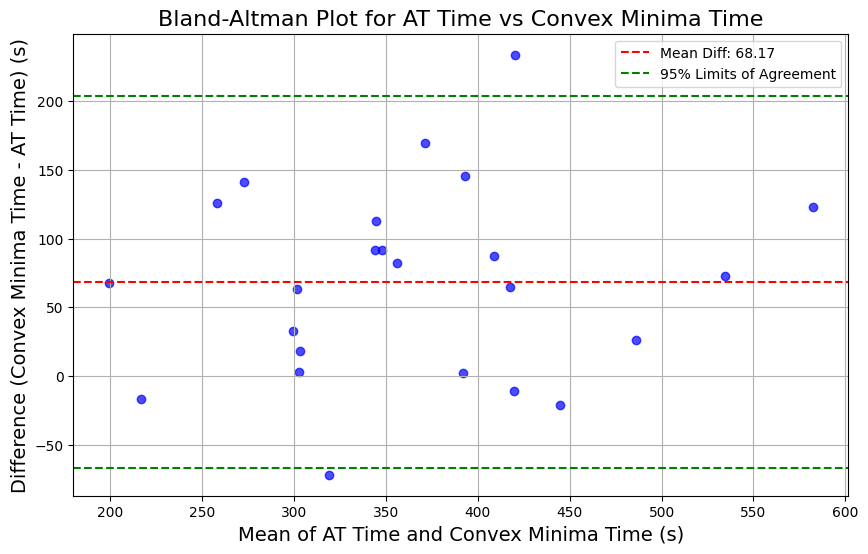

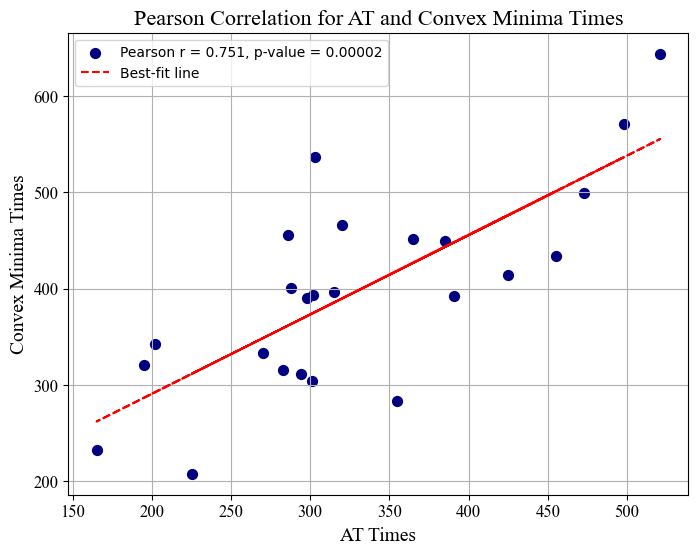

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude subject 13
filtered_results = results_df[results_df['Subject'] != 13].dropna(subset=['AT_time', 'Convex_Minima_Time'])

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

Applying this final search window achieves the highest correlation as expected, thus concluding this exploratory analysis. This methodology is then applied to a new unseen dataset in the Rule-Based RQE notebook. 